In [1]:
%load_ext autoreload
%autoreload 2

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from utils import get_eval_stats
import scipy

In [2]:
target_protein=None
test_dir = "/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/test/"
valid_dir = "/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/validation/"
summary_func = np.mean

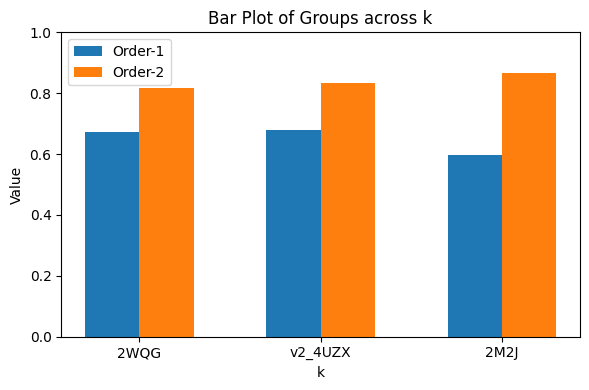

In [3]:
prot1 = {
    "name": "2WQG",
    "order": [1,2,3],
    "r2": [0.6726, 0.816, 0.8927],
    "len": 41
}

prot2 = {
    "name": "v2_4UZX",
    "order": [1,2],
    "r2": [0.6782, 0.8328, 0.9],
    "len": 58
}

prot3 = {
    "name": "2M2J",
    "order": [1,2],
    "r2": [0.598, 0.8676, 0.9],
    "len": 71
}

proteins = [prot1, prot2, prot3]

k_vals = [prot['name'] for prot in proteins]

x = np.arange(len(k_vals))
width = 0.3

plt.figure(figsize=(6, 4))

plt.bar(x - width/2, [p['r2'][0] for p in proteins], width, label="Order-1")
plt.bar(x +width/2, [p['r2'][1] for p in proteins], width, label="Order-2")
# plt.bar(x + width, [p['r2'][2] for p in proteins], width, label="Order-3")

plt.xlabel('k')
plt.ylabel('Value')
plt.title('Bar Plot of Groups across k')
plt.xticks(x, k_vals)
plt.legend()
plt.ylim(0,1)

plt.tight_layout()
plt.show()

In [4]:
#################################

drakes_df = pd.read_csv(test_dir + "drakes_test.csv")
pretrained_df = pd.read_csv(test_dir + "pretrained_test.csv")

drakes_eval_stats = get_eval_stats(drakes_df, target_protein=target_protein, summary_func=summary_func)
pre_eval_stats = get_eval_stats(pretrained_df, target_protein=target_protein, summary_func=summary_func)

drakes_ddg_align = drakes_eval_stats['ddg_align']
pre_ddg_align = pre_eval_stats['ddg_align']

#################################

bon10_df = pd.read_csv(test_dir + "target/group1/pretrained_test_ddg_bon_N=10.csv")
bon50_df = pd.read_csv(test_dir + "target/group1/pretrained_test_ddg_bon_N=50.csv")

bon10_eval_stats = get_eval_stats(bon10_df, target_protein=target_protein, summary_func=summary_func)
bon50_eval_stats = get_eval_stats(bon50_df, target_protein=target_protein, summary_func=summary_func)

bon10_ddg_align = bon10_eval_stats['ddg_align']
bon50_ddg_align = bon50_eval_stats['ddg_align']

#################################

spec10_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192.csv")
spec10_rl_df = pd.read_csv(test_dir + "target/group1/" + "drakes_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192.csv")
spec10_eval_stats = get_eval_stats(spec10_df, target_protein=target_protein, summary_func=summary_func)
spec10_rl_eval_stats = get_eval_stats(spec10_rl_df, target_protein=target_protein, summary_func=summary_func)

#################################
rmax=True
spec10_bon10_df = pd.read_csv(test_dir + "target/group1/" + f"pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192_rmax={rmax}.csv")
spec10_bon10_ll_df = pd.read_csv(test_dir + "target/group1/" + f"pretrained_test_protgpt_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192_rmax=True.csv")
spec10_ll_df = pd.read_csv(test_dir + "target/group1/" + f"pretrained_test_protgpt_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192_rmax=False.csv")

spec10_bon10_eval_stats = get_eval_stats(spec10_bon10_df, target_protein=target_protein, summary_func=summary_func)
spec10_bon10_ll_eval_stats = get_eval_stats(spec10_bon10_ll_df, target_protein=target_protein, summary_func=summary_func)
spec10_ll_eval_stats = get_eval_stats(spec10_ll_df, target_protein=target_protein, summary_func=summary_func)

ex10_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=exclusion_maxspecorder=10.csv")
ex10_eval_stats = get_eval_stats(ex10_df, target_protein=target_protein, summary_func=summary_func)
ex10_bon10_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=exclusion_maxspecorder=10.csv")
ex10_bon10_eval_stats = get_eval_stats(ex10_bon10_df, target_protein=target_protein, summary_func=summary_func)

#################################

lsq10_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=lasso_maxspecorder=10_masks=8192_lassolambda=0.0.csv")
lsq10_rl_df = pd.read_csv(test_dir + "target/group1/" + "drakes_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=lasso_maxspecorder=10_masks=8192_lassolambda=0.0.csv")
lsq10_eval_stats = get_eval_stats(lsq10_df, target_protein=target_protein, summary_func=summary_func)
lsq10_rl_eval_stats = get_eval_stats(lsq10_rl_df, target_protein=target_protein, summary_func=summary_func)

#################################

lsq10_bon10_df = pd.read_csv(test_dir + "target/group1/" + f"pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=lasso_maxspecorder=10_masks=8192_rmax={rmax}_lassolambda=0.0.csv")
lsq10_bon10_eval_stats = get_eval_stats(lsq10_bon10_df, target_protein=target_protein, summary_func=summary_func)

#################################
# spec20, spec20_bon10, and spec20_rl dfs using CORRECT ABSOLUTE file paths as done in neurips_figures1.ipynb

neurips_dir = "/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/neurips/"
# spec20: 32678 results from neurips/remove
spec20_df = pd.read_csv(neurips_dir + "remove/pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=32768_rmax=False_.csv")

# bon and drakes are in neurips eval results directory
spec20_bon10_df = pd.read_csv(neurips_dir + "pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=8192_rmax=True_.csv")
spec20_rl_df = pd.read_csv(neurips_dir + "drakes_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=8192_rmax=False_.csv")

spec20_eval_stats = get_eval_stats(spec20_df, target_protein=target_protein, summary_func=summary_func)
spec20_bon10_eval_stats = get_eval_stats(spec20_bon10_df, target_protein=target_protein, summary_func=summary_func)
spec20_rl_eval_stats = get_eval_stats(spec20_rl_df, target_protein=target_protein, summary_func=summary_func)

FileNotFoundError: [Errno 2] No such file or directory: '/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/test/drakes_test.csv'

In [ ]:
def display_traj(df_lst, names, traj_col, ylabel, colors=None, target_protein=None, ylim=None, it_space=None, title="Protein Evaluation Trajectory", show_bon=True, show_baselines=True, show_err=True):
    trajectories = []
    for df in df_lst:
        avg_traj, std_err = calc_avg_traj(df, traj_col, target_protein=target_protein)
        trajectories.append((avg_traj, std_err))

    if it_space is None:
        it_space = np.arange(trajectories[0][0].shape[0])

    if traj_col == "spec_trajectory" and show_baselines:
        plt.axhline(drakes_ddg_align, color="#984B6B", linestyle='--', label='DRAKES', linewidth=1)
        if show_bon:
            plt.axhline(bon50_ddg_align, color='#483AF2', linestyle='--', label='BoN-50', linewidth=1)
            plt.axhline(bon10_ddg_align, color="#BF5FA7", linestyle='--', label='BoN-10', linewidth=1)
        plt.axhline(pre_ddg_align, color='#E655C1', linestyle='--', label='Pretrained', linewidth=1)

    for i, ((traj, err), name) in enumerate(zip(trajectories, names)):
        print(name, traj)
        if colors is not None:
            plt.plot(it_space, traj, label=name, color=colors[i % len(colors)])
            if show_err: plt.fill_between(it_space, traj - err, traj + err, color=colors[i % len(colors)], alpha=0.2)
        else:
            plt.plot(it_space, traj, label=name)
            if show_err: plt.fill_between(it_space, traj - err, traj + err, alpha=0.1)

    plt.xlabel("Feedback Iterations")
    plt.ylabel(ylabel)
    protein_info = "" if target_protein is None else f": {target_protein}"
    plt.title(title+protein_info)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, frameon=False)
    plt.xlim(it_space[0], it_space[-1])
    if ylim is not None:
        plt.ylim(ylim)
    plt.show()

0.209324205618 0.34267065678
0.209324205618 0.34267065678
0.209324205618 0.34267065677999997


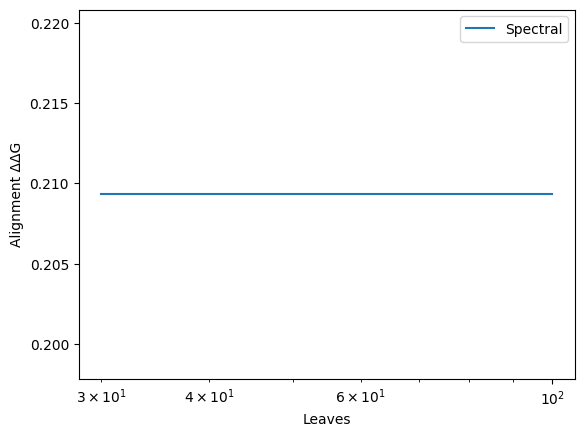

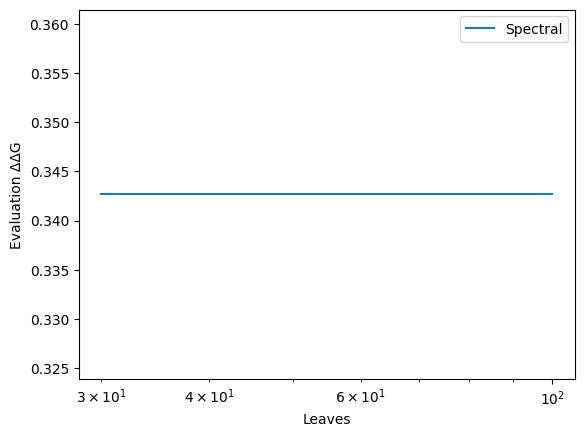

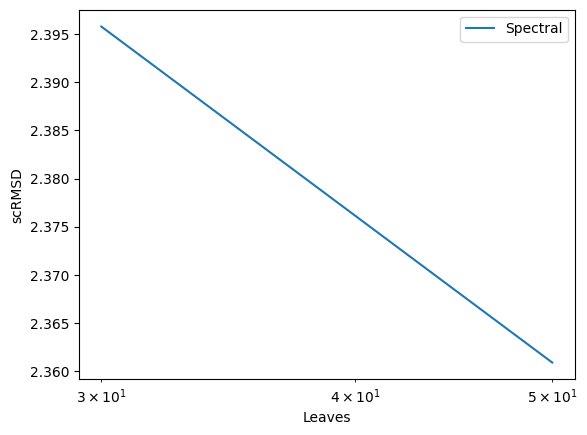

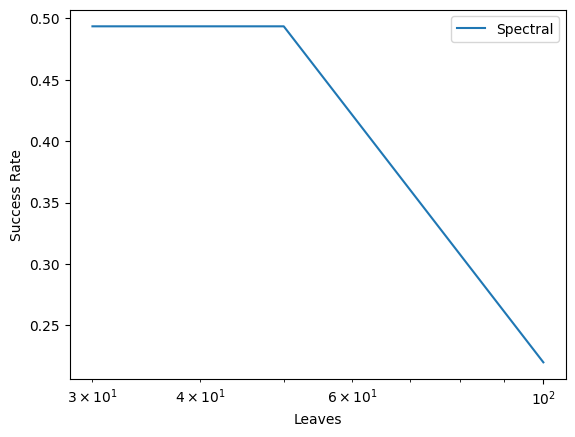

In [ ]:
leaves = [30, 50, 100] # 2048 is good enough
spec_order_dfs = []
lsq_order_dfs = []
spec_order_stats = []
lsq_order_stats = []
for n in leaves:   
    fn_spec = valid_dir + f'anvil_data/pretrained_validation_ddg_bon_N=1_feedbacksteps=3_feedbackmethod=spectral_maxspecorder=10_masks=2048_rmax=False_"num_leaves"={n}_"learning_rate"=0.01_"max_depth"=5_"lambda_l1"=0.0001.csv'

    df_spec = pd.read_csv(fn_spec)
    
    stats_spec = get_eval_stats(df_spec, target_protein=target_protein, summary_func=summary_func)
    spec_order_dfs.append(df_spec)
    spec_order_stats.append(stats_spec)
    print(stats_spec['ddg_align'], stats_spec['ddg'])
    
def plot_stuff(attribute, xlabel, ylabel, title):

    plt.plot(leaves, [s[attribute] for s in spec_order_stats], label="Spectral")
    plt.legend()
    plt.xscale('log')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


plot_stuff('ddg_align', 'Leaves', 'Alignment ΔΔG', "")
plot_stuff('ddg', 'Leaves', 'Evaluation ΔΔG', "")
plot_stuff('scrmsd', 'Leaves', 'scRMSD', "")
plot_stuff("success_rate", 'Leaves', 'Success Rate', "")

0.16019373680333332 0.3308460581
0.209324205618 0.34267065678


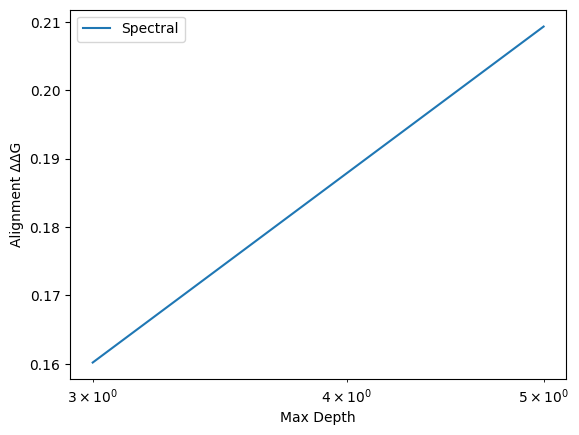

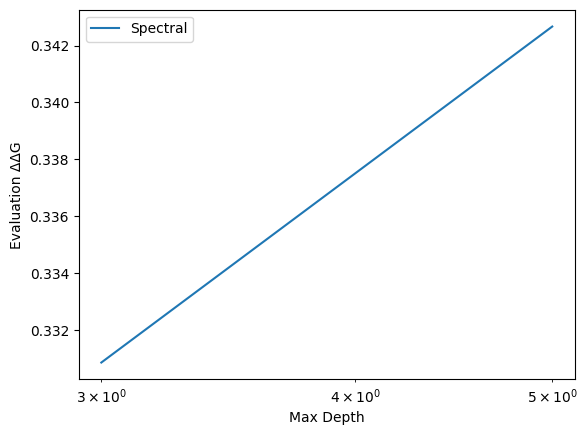

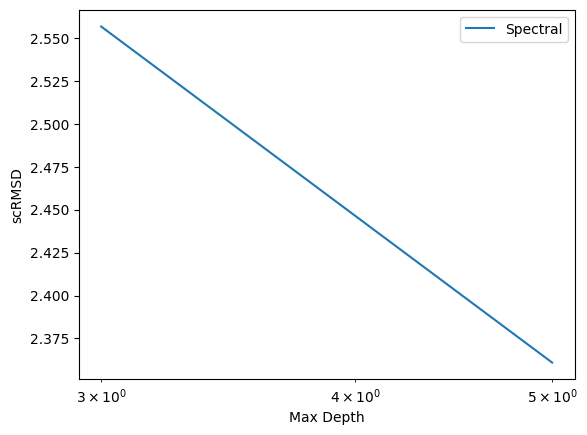

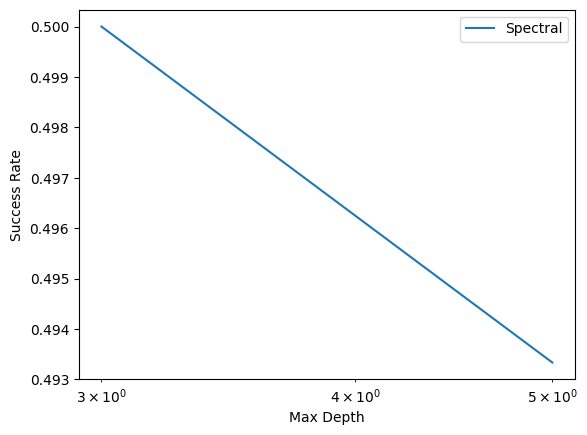

In [ ]:
depths = [3, 5] # 2048 is good enough
spec_order_dfs = []
lsq_order_dfs = []
spec_order_stats = []
lsq_order_stats = []
for d in depths:   
    fn_spec = valid_dir + f'anvil_data/pretrained_validation_ddg_bon_N=1_feedbacksteps=3_feedbackmethod=spectral_maxspecorder=10_masks=2048_rmax=False_"num_leaves"=50_"learning_rate"=0.01_"max_depth"={d}_"lambda_l1"=0.0001.csv'

    df_spec = pd.read_csv(fn_spec)
    
    stats_spec = get_eval_stats(df_spec, target_protein=target_protein, summary_func=summary_func)
    spec_order_dfs.append(df_spec)
    spec_order_stats.append(stats_spec)
    print(stats_spec['ddg_align'], stats_spec['ddg'])
    
def plot_stuff(attribute, xlabel, ylabel, title):

    plt.plot(depths, [s[attribute] for s in spec_order_stats], label="Spectral")
    plt.legend()
    plt.xscale('log')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


plot_stuff('ddg_align', 'Max Depth', 'Alignment ΔΔG', "")
plot_stuff('ddg', 'Max Depth', 'Evaluation ΔΔG', "")
plot_stuff('scrmsd', 'Max Depth', 'scRMSD', "")
plot_stuff("success_rate", 'Max Depth', 'Success Rate', "")

0.4809686733666668 0.3522458172933332
0.48040582989999997 0.34267065678
0.46710433897866666 0.36235646598666665
0.24944416077999998 0.35923798738
-0.04734399498666669 0.37495450008666664


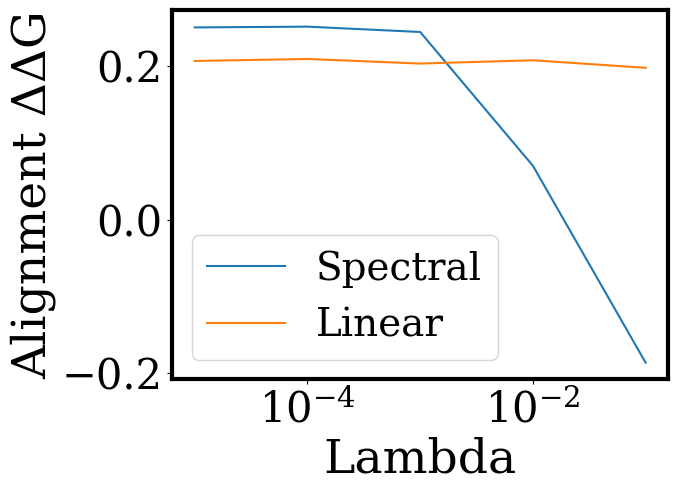

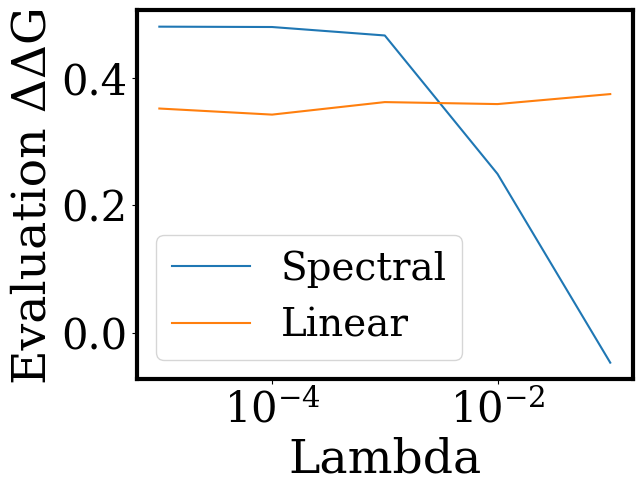

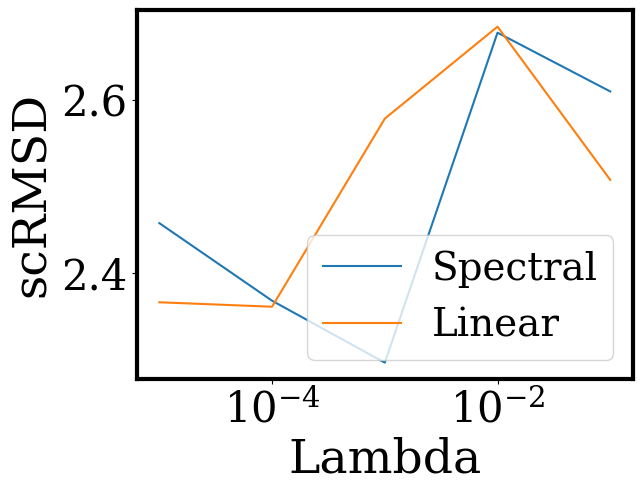

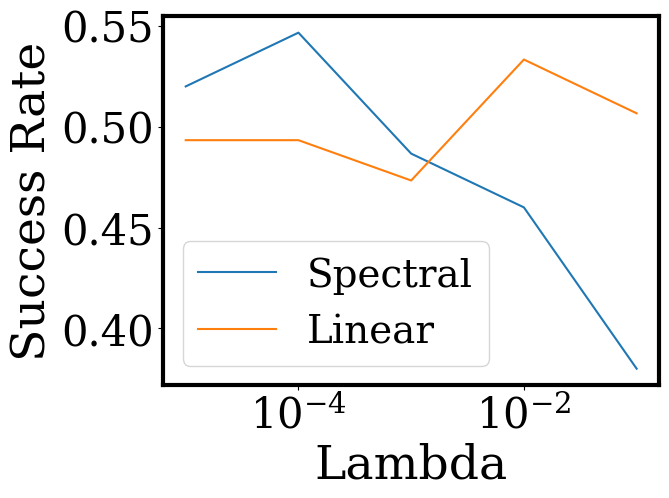

In [ ]:
# Spectral: 
# lambda=0.00001
# masks=2048
# learning_rate=0.01
# max_depth=5
# edits=20
# iterations=5

lambdas = ["0.00001", "0.0001", "0.001", "0.01", "0.1"]
spec_order_dfs = []
lsq_order_dfs = []
spec_order_stats = []
lsq_order_stats = []
for lam in lambdas:
    fn_spec = valid_dir + f"anvil_data/pretrained_validation_ddg_bon_N=1_feedbacksteps=3_feedbackmethod=lasso_maxspecorder=10_masks=2048_rmax=False_lassolambda={lam}.csv"
    fn_lsq = valid_dir + f'anvil_data/pretrained_validation_ddg_bon_N=1_feedbacksteps=3_feedbackmethod=spectral_maxspecorder=10_masks=2048_rmax=False_"num_leaves"=50_"learning_rate"=0.01_"max_depth"=5_"lambda_l1"={lam}.csv'
    
    df_spec = pd.read_csv(fn_spec)
    df_lsq = pd.read_csv(fn_lsq)
    
    stats_spec = get_eval_stats(df_spec, target_protein=target_protein, summary_func=summary_func)
    stats_lsq = get_eval_stats(df_lsq, target_protein=target_protein, summary_func=summary_func)
    spec_order_dfs.append(df_spec)
    lsq_order_dfs.append(df_lsq)
    spec_order_stats.append(stats_spec)
    lsq_order_stats.append(stats_lsq)
    # print(stats['ddg'], stats['ddg_align'], stats['scrmsd'], stats['success_rate'], stats['pos_ddg_prop'], stats['low_scrmsd_prop'])
    print(stats_spec['ddg'], stats_lsq['ddg'])

def plot_stuff(attribute, xlabel, ylabel, title, log_scale=False):
    float_lambdas = [float(lam) for lam in lambdas]
    plt.plot(float_lambdas, [s[attribute] for s in spec_order_stats], label="Spectral")
    plt.plot(float_lambdas, [s[attribute] for s in lsq_order_stats], label="Linear")
    plt.legend()
    if log_scale:
        plt.xscale('log')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


plot_stuff('ddg_align', 'Lambda', 'Alignment ΔΔG', "", log_scale=True)
plot_stuff('ddg', 'Lambda', 'Evaluation ΔΔG', "", log_scale=True)
plot_stuff('scrmsd', 'Lambda', 'scRMSD', "", log_scale=True)
plot_stuff("success_rate", 'Lambda', 'Success Rate', "", log_scale=True)

In [ ]:
spec_masks = [64, 256, 1024, 4096, 32768]
bon_order_dfs = []
lin_order_dfs = []
bon_order_stats = []
lin_order_stats = []

spec_fn = test_dir + f'pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=32768_rmax=True_.csv'
spec_df = pd.read_csv(spec_fn)
spec_stats = get_eval_stats(spec_df, target_protein=target_protein, summary_func=summary_func)
print(spec_stats['ddg_align'], spec_stats['ddg'])

for n in spec_masks:   
    lin_fn = test_dir + f'delta_data/pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=lasso_maxspecorder=20_masks={n}_rmax=False_lassolambda=0.0001.csv'
    bon_fn = test_dir + f'delta_data/pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=max-mask_maxspecorder=20_masks={n}_rmax=False.csv'

    lin_df = pd.read_csv(lin_fn)
    bon_df = pd.read_csv(bon_fn)

    stats_lin = get_eval_stats(lin_df, target_protein=target_protein, summary_func=summary_func)
    stats_bon = get_eval_stats(bon_df, target_protein=target_protein, summary_func=summary_func)

    lin_order_dfs.append(lin_df)
    bon_order_dfs.append(bon_df)
    lin_order_stats.append(stats_lin)
    bon_order_stats.append(stats_bon)
    print(stats_bon['ddg_align'], stats_bon['ddg'])
    
def plot_stuff(attribute, xlabel, ylabel, title):

    plt.plot(spec_masks, [s[attribute] for s in bon_order_stats], label="BoN")
    plt.plot(spec_masks, [s[attribute] for s in lin_order_stats], label="LASSO")
    plt.axhline(spec_stats[attribute], color='gray', linestyle='--', label='Spectral', linewidth=1)
    plt.legend()
    plt.xscale('log')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


plot_stuff('ddg_align', 'Training Samples', 'Alignment ΔΔG', "")
plot_stuff('ddg', 'Training Samples', 'Evaluation ΔΔG', "")
# plot_stuff('scrmsd', 'Training Samples', 'scRMSD', "")
# plot_stuff("success_rate", 'Training Samples', 'Success Rate', "")

FileNotFoundError: [Errno 2] No such file or directory: '/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/test/pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=32768_rmax=True_.csv'

In [ ]:
spec_masks = [256, 512, 2048, 8192, 32768] # 2048 is good enough
spec_order_dfs = []
lsq_order_dfs = []
spec_order_stats = []
lsq_order_stats = []

fn_spec = test_dir + 'pretrained_validation_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=128_rmax=False_"num_leaves"=50_"learning_rate"=0.01_"max_depth"=5_"lambda_l1"=0.00001.csv'
df_spec = pd.read_csv(fn_spec)

stats_spec = get_eval_stats(df_spec, target_protein=target_protein, summary_func=summary_func)
spec_order_dfs.append(df_spec)
spec_order_stats.append(stats_spec)
print(stats_spec['ddg_align'], stats_spec['ddg'])


for n in spec_masks:   
    fn_spec = valid_dir + f'anvil_data/pretrained_validation_ddg_bon_N=1_feedbacksteps=3_feedbackmethod=spectral_maxspecorder=10_masks={n}_rmax=False_"num_leaves"=50_"learning_rate"=0.01_"max_depth"=5_"lambda_l1"=0.0001.csv'

    df_spec = pd.read_csv(fn_spec)
    
    stats_spec = get_eval_stats(df_spec, target_protein=target_protein, summary_func=summary_func)
    spec_order_dfs.append(df_spec)
    spec_order_stats.append(stats_spec)
    print(stats_spec['ddg_align'], stats_spec['ddg'])
    
spec_masks = [128] + spec_masks
    
def plot_stuff(attribute, xlabel, ylabel, title):

    plt.plot(spec_masks, [s[attribute] for s in spec_order_stats], label="Spectral")
    plt.legend()
    plt.xscale('log')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


plot_stuff('ddg_align', 'Training Samples', 'Alignment ΔΔG', "")
plot_stuff('ddg', 'Training Samples', 'Evaluation ΔΔG', "")
# plot_stuff('scrmsd', 'Training Samples', 'scRMSD', "")
# plot_stuff("success_rate", 'Training Samples', 'Success Rate', "")

FileNotFoundError: [Errno 2] No such file or directory: '/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/test/pretrained_validation_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=128_rmax=False_"num_leaves"=50_"learning_rate"=0.01_"max_depth"=5_"lambda_l1"=0.00001.csv'

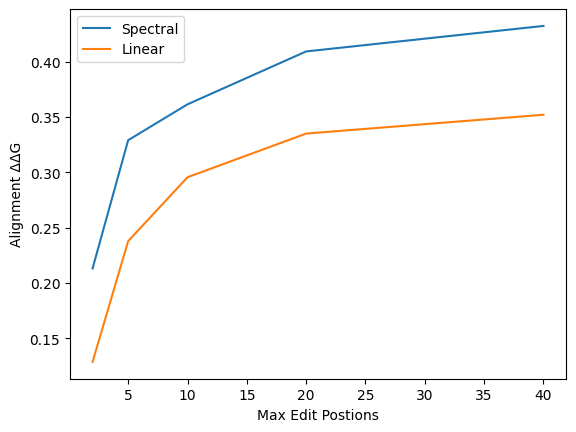

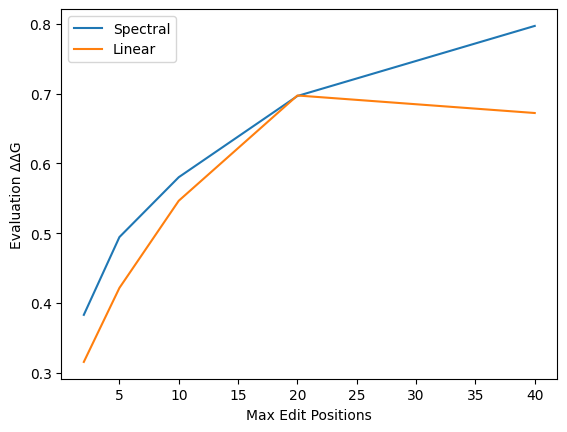

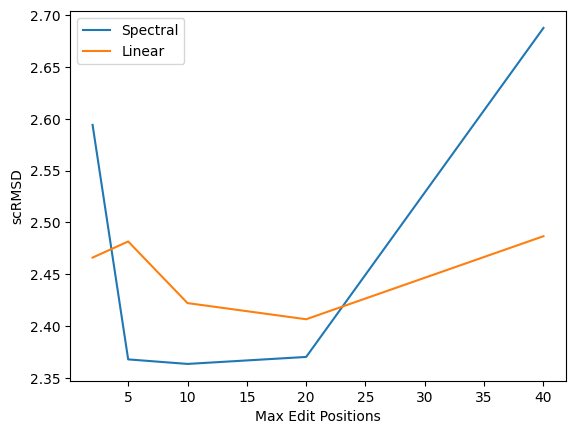

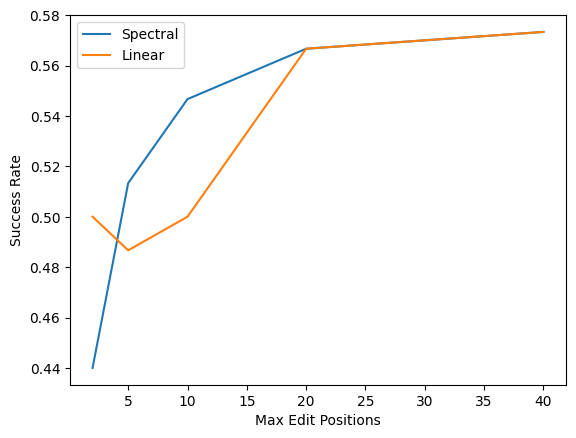

In [ ]:
spec_orders = [2, 5, 10, 20, 40]
spec_order_dfs = []
lsq_order_dfs = []
spec_order_stats = []
lsq_order_stats = []
for order in spec_orders:
    fn_spec = valid_dir + f"spec_order_valid/pretrained_validation_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder={order}_masks=8192_rmax=False.csv"
    fn_lsq = valid_dir + f"spec_order_valid/pretrained_validation_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=lasso_maxspecorder={order}_masks=8192_rmax=False_lassolambda=0.0.csv"
    
    df_spec = pd.read_csv(fn_spec)
    df_lsq = pd.read_csv(fn_lsq)
    
    stats_spec = get_eval_stats(df_spec, target_protein=target_protein, summary_func=summary_func)
    stats_lsq = get_eval_stats(df_lsq, target_protein=target_protein, summary_func=summary_func)
    spec_order_dfs.append(df_spec)
    lsq_order_dfs.append(df_lsq)
    spec_order_stats.append(stats_spec)
    lsq_order_stats.append(stats_lsq)
    # print(stats['ddg'], stats['ddg_align'], stats['scrmsd'], stats['success_rate'], stats['pos_ddg_prop'], stats['low_scrmsd_prop'])
    
def plot_stuff(attribute, xlabel, ylabel, title):

    plt.plot(spec_orders, [s[attribute] for s in spec_order_stats], label="Spectral")
    plt.plot(spec_orders, [s[attribute] for s in lsq_order_stats], label="Linear")
    plt.legend()
    # plt.xscale('log')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


plot_stuff('ddg_align', 'Max Edit Postions', 'Alignment ΔΔG', "")
plot_stuff('ddg', 'Max Edit Positions', 'Evaluation ΔΔG', "")
plot_stuff('scrmsd', 'Max Edit Positions', 'scRMSD', "")
plot_stuff("success_rate", 'Max Edit Positions', 'Success Rate', "")

In [ ]:
print(pre_eval_stats)
print(drakes_eval_stats)
print(bon10_eval_stats)
print(bon50_eval_stats)
print()
print(spec10_eval_stats)
print(spec10_bon10_eval_stats)
print(spec10_rl_eval_stats)
print()
print(spec20_eval_stats)
print(spec20_bon10_eval_stats)
print(spec20_rl_eval_stats)
# print(spec10_bon10_ll_eval_stats)
# print(spec10_ll_eval_stats)

{'ddg': -0.48895850835836585, 'ddg_std': 1.284352746810967, 'pos_ddg_prop': 0.3606770833333333, 'ddg_align': 0.10384784387302082, 'ddg_align_std': 0.42305642930010257, 'scrmsd': 1.1023916411407602, 'scrmsd_std': 0.8554886584567372, 'low_scrmsd_prop': 0.91796875, 'success_rate': 0.3391927083333333, 'll': -147.8452356904745, 'll_std': 43.31352220688458}
{'ddg': 0.9882918555138019, 'ddg_std': 0.8210351286830646, 'pos_ddg_prop': 0.8587239583333334, 'ddg_align': 0.6931964156210938, 'ddg_align_std': 0.09659150250666441, 'scrmsd': 1.1722478033043444, 'scrmsd_std': 1.202034489322876, 'low_scrmsd_prop': 0.9342447916666666, 'success_rate': 0.7975260416666666, 'll': -157.515934313337, 'll_std': 41.5608073079779}
{'ddg': 0.09319000237031254, 'ddg_std': 1.2250946129260123, 'pos_ddg_prop': 0.59375, 'ddg_align': 0.4539926005006511, 'ddg_align_std': 0.20337805267767164, 'scrmsd': 1.0877057711865443, 'scrmsd_std': 0.8287947013514272, 'low_scrmsd_prop': 0.9244791666666666, 'success_rate': 0.560546875, '

In [ ]:
spec10_tar_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_HEEH_KT_rd6_0746_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192.csv")
lsq10_tar_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_HEEH_KT_rd6_0746_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=lasso_maxspecorder=10_masks=8192_lassolambda=0.0.csv")
ex10_tar_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_HEEH_KT_rd6_0746_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=exclusion_maxspecorder=10.csv")

In [ ]:
def display_stat_comp(stats, names, target_stat, ylabel, title, ylim=None, yscale=1):
    heights = [s[target_stat] * yscale for s in stats]

    cmap = plt.cm.Blues # type: ignore
    colors = cmap(np.linspace(0.4, 0.8, len(names)))

    bars = plt.bar(names, heights, color=colors)

    plt.ylabel(ylabel)
    plt.title(title)

    if ylim is not None:
        plt.ylim(ylim)


    # Label bars
    for bar, value in zip(bars, heights):
        if target_stat == 'ddg_align' or target_stat == 'ddg':
            value_str = f"{value:.2f}"
        elif target_stat == 'scrmsd':
            value_str = f"{value:.2f}"
        elif target_stat == 'll':
            value_str = f"{value:.1f}"
        elif target_stat == 'success_rate':
            value_str = f"{value:.1f}"
        else:
            value_str = str(value)
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            value_str,
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.xticks(rotation=45)
    plt.show()

def display_all_info(stats, names):
    display_stat_comp(stats, names, "ddg_align", "Average Predicted ΔΔG", "Alignment ΔΔG Oracle Comparison")
    display_stat_comp(stats, names, "ddg", "Average Evaluation ΔΔG", "Evaluation ΔΔG Oracle Comparison")
    display_stat_comp(stats, names, "ll", "Average ProtGPT2 Negative Log Likelihood", "Log Likelihood for ΔΔG Alignment", yscale=-1, ylim=120)
    display_stat_comp(stats, names, "scrmsd", "scRMSD", "scRMSD for ΔΔG Alignment", ylim=(0,2))
    display_stat_comp(stats, names, "success_rate", "Success Rate (%)", "Protein Success Comparison", ylim=(0,100), yscale=100)

In [ ]:
# # stats = [pre_eval_stats, drakes_eval_stats, bon10_eval_stats, bon50_eval_stats, lsq10_eval_stats, spec10_eval_stats, lsq10_bon10_eval_stats, spec10_bon10_eval_stats]
# # names = ["Pretrained", "DRAKES", "BoN-10", "BoN-50", "Linear-10", "Spec-10", "Linear-10 BoN-10", "Spec-10 BoN-10",]

# stats = [pre_eval_stats, drakes_eval_stats, spec10_bon10_eval_stats, lsq10_bon10_eval_stats]
# names = ["Pretrained", "DRAKES", "Spec-10 BoN-10", "Linear-10 BoN-10"]


# for n, s1 in zip(names, stats):
#     print(n, round(s1['ddg_align'], 2))

# display_all_info(stats, names)

In [38]:
# # Follow up on median vs mean evaluation
# stats2 = [pre_eval_stats, ex10_ll_eval_stats, lsq10_ll_eval_stats, spec10_ll_eval_stats]
# names2 = ["Pretrained", "Exclusion-10", "Linear-10", "Spec-10"]
# display_stat_comp(stats2, names2, "ll", "Average ProtGPT2 Negative Log Likelihood", "Log Likelihood Alignment", yscale=-1, ylim=120)

In [39]:
# seq_recovery,seq,true_seq,protein_name,top_spec_interactions,spec_selections,spec_trajectory,r2_trajectory,loglikelihood,ddg,ddg_eval,scrmsd

In [40]:
def calc_avg_traj(df, traj_col, target_protein=None):
    if target_protein is not None:
        df = df[df['protein_name'] == target_protein + ".pdb"]
    
    protein_names = set(df['protein_name'])

    cluster_means = []
    for p in protein_names:
        df_p = df[df['protein_name'] == p]
        traj_p = np.array([eval(lst) for lst in df_p[traj_col].tolist()])
        cluster_means.append(np.mean(traj_p, axis=0))

    avg_traj = np.mean(cluster_means, axis=0)

    # Standard error calculations
    std_errors = []
    for p in protein_names:
        df_p = df[df['protein_name'] == p]
        traj_p = np.array([eval(lst) for lst in df_p[traj_col].tolist()])
        std_err = scipy.stats.sem(traj_p, axis=0)
        std_errors.append(std_err)

    N = len(protein_names)
    std_errors = np.array(std_errors)
    std_err = np.sqrt(np.sum(std_errors**2, axis=0)) / N
    
    return avg_traj, std_err

def display_traj(df_lst, names, traj_col, ylabel, colors=None, target_protein=None, ylim=None, it_space=None, title="Protein Evaluation Trajectory", show_bon=True, show_baselines=True, show_err=True):
    trajectories = []
    for df in df_lst:
        avg_traj, std_err = calc_avg_traj(df, traj_col, target_protein=target_protein)
        trajectories.append((avg_traj, std_err))

    if it_space is None:
        it_space = np.arange(min([traj[0].shape[0] for traj in trajectories]))

    if traj_col == "spec_trajectory" and show_baselines:
        plt.axhline(drakes_ddg_align, color="#984B6B", linestyle='--', label='DRAKES', linewidth=1)
        if show_bon:
            plt.axhline(bon50_ddg_align, color='#483AF2', linestyle='--', label='BoN-50', linewidth=1)
            plt.axhline(bon10_ddg_align, color="#BF5FA7", linestyle='--', label='BoN-10', linewidth=1)
        plt.axhline(pre_ddg_align, color='#E655C1', linestyle='--', label='Pretrained', linewidth=1)

    for i, ((traj, err), name) in enumerate(zip(trajectories, names)):
        traj, err = traj[:len(it_space)], err[:len(it_space)]
        print(name, traj)
        if colors is not None:
            plt.plot(it_space, traj, label=name, color=colors[i % len(colors)])
            if show_err: plt.fill_between(it_space, traj - err, traj + err, color=colors[i % len(colors)], alpha=0.2)
        else:
            plt.plot(it_space, traj, label=name)
            if show_err: plt.fill_between(it_space, traj - err, traj + err, alpha=0.1)

    plt.xlabel("Feedback Iterations")
    plt.ylabel(ylabel)
    protein_info = "" if target_protein is None else f": {target_protein}"
    plt.title(title+protein_info)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, frameon=False)
    plt.xlim(it_space[0], it_space[-1])
    plt.xticks(it_space[::len(it_space) // min(5, len(it_space))])
    if ylim is not None:
        plt.ylim(ylim)
    plt.show()

In [41]:
def traj_full_comp(dfs, names, colors, show_baselines=True, show_bon=True, title="ΔΔG Spectral Edit Selection Reward Trajectories"):
    traj_col = 'spec_trajectory'
    ylabel = "Average Predicted ΔΔG"
    ylim = None
    it_space = None

    display_traj(dfs, names, traj_col, ylabel, colors=colors, ylim=ylim, it_space=it_space, target_protein=target_protein, title=title, show_err=True, show_bon=show_bon, show_baselines=show_baselines)

def traj_r2_comp(dfs, names, colors):
    traj_col = 'r2_trajectory'
    ylabel = "Average r2"
    ylim = (0, 1)
    it_space = np.arange(1, 6, 1)
    title = "ΔΔG Spectral Edit Selection R-Squared Values"

    display_traj(dfs, names, traj_col, ylabel, colors=colors, ylim=ylim, it_space=it_space, target_protein=target_protein, title=title, show_err=False)

In [42]:
dfs = [spec10_rl_df, spec10_bon10_df, spec10_df]#, lsq10_rl_df, lsq10_bon10_df, lsq10_df, ex10_df]
names = ['Spectral-10 DRAKES', 'Spectral-10 BoN-10', 'Spectral-10']#, 'Linear-10 DRAKES', 'Linear-10 BoN-10', 'Linear-10', 'Exclusion-10']
colors = ["#6195F4", "#3AD2F2", "#61F4BC","#D68BF2", "#E655C1", "#BF5F87", 'green']

traj_full_comp(dfs, names, colors)

Spectral-10 DRAKES [0.6923039  0.77254839 0.79871191 0.80910188 0.8160452  0.8216377 ]
Spectral-10 BoN-10 [0.4661458  0.58973692 0.62072908 0.63569574 0.64601547 0.65228229]
Spectral-10 [0.10109452 0.38193804 0.45154131 0.47496291 0.49170477 0.50331066]


In [43]:
dfs = spec_order_dfs
names = [f"k={k}" for k in spec_orders]

traj_full_comp(dfs, names, colors, show_baselines=False)

NameError: name 'spec_orders' is not defined

In [ ]:
# dfs = [spec10_bon10_ll_df, spec10_ll_df]
# names = ['Spectral-10 BoN-10', 'Spectral-10']#, 'Linear-10 DRAKES', 'Linear-10 BoN-10', 'Linear-10', 'Exclusion-10']
# colors = [ "#3AD2F2","#D68BF2",]

# traj_full_comp(dfs, names, colors, show_baselines=False)

Spectral-10 BoN-10 [0.4661458  0.58973692 0.62072908 0.63569574 0.64601547 0.65228229]
Linear-10 BoN-10 [0.4661458  0.57840899 0.60785018 0.6195163  0.62637912 0.62986666]
Exclusion-10 BoN-10 [0.4661458  0.54360022 0.56210541 0.57256262 0.57662785 0.58387976]


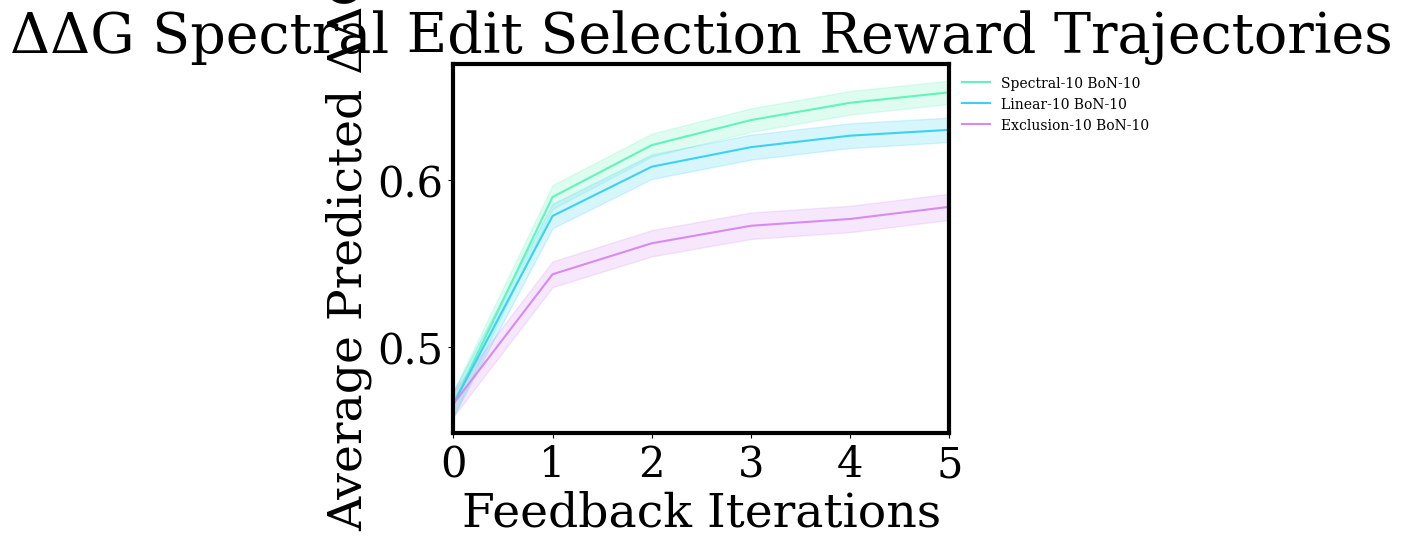

In [44]:
dfs = [spec10_bon10_df, lsq10_bon10_df, ex10_bon10_df]
names = ['Spectral-10 BoN-10', 'Linear-10 BoN-10', 'Exclusion-10 BoN-10']
colors = ["#61F4BC", "#3AD2F2", "#D68BF2"]

traj_full_comp(dfs, names, colors, show_baselines=False) # r6_560_TrROS_Hall - Big Difference # 2KRU almost the same

In [45]:
lasso = test_dir + "heldout/" + "pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=lasso_maxspecorder=20_masks=32768_rmax=True_lassolambda=1e-05.csv"
bon = test_dir + "heldout/" + "pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=max-mask_maxspecorder=20_masks=32768_rmax=True.csv"
spec = test_dir + "heldout/" + "pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=32768_rmax=True.csv"

df_lasso = pd.read_csv(lasso)
df_bon = pd.read_csv(bon)
df_spec = pd.read_csv(spec)

dfs = [df_spec, df_bon, ex10_bon10_df]
colors = ["#61F4BC", "#D68BF2", "#5585E6"]
names = ["Spectral", "Max-Mask", "Exclusion"]
traj_full_comp(dfs, names, colors, show_baselines=False, title="ΔΔG Reward Trajectories with Best-of-10")

Spectral [0.4661458  0.61494028 0.64702012 0.66465114 0.67555147 0.68288793]
Max-Mask [0.46614568 0.58954695 0.63076194 0.6533887  0.66620196 0.68020166]


Exclusion [0.4661458  0.54360022 0.56210541 0.57256262 0.57662785 0.58387976]


Spectral-10 [0.10109452 0.38193804 0.45154131 0.47496291 0.49170477 0.50331066]
Linear-10 [0.10109452 0.36537153 0.41624659 0.44409737 0.46137947 0.46723969]
Exclusion-10 [0.10109452 0.30103304 0.33344879 0.35306276 0.364261   0.37593306]


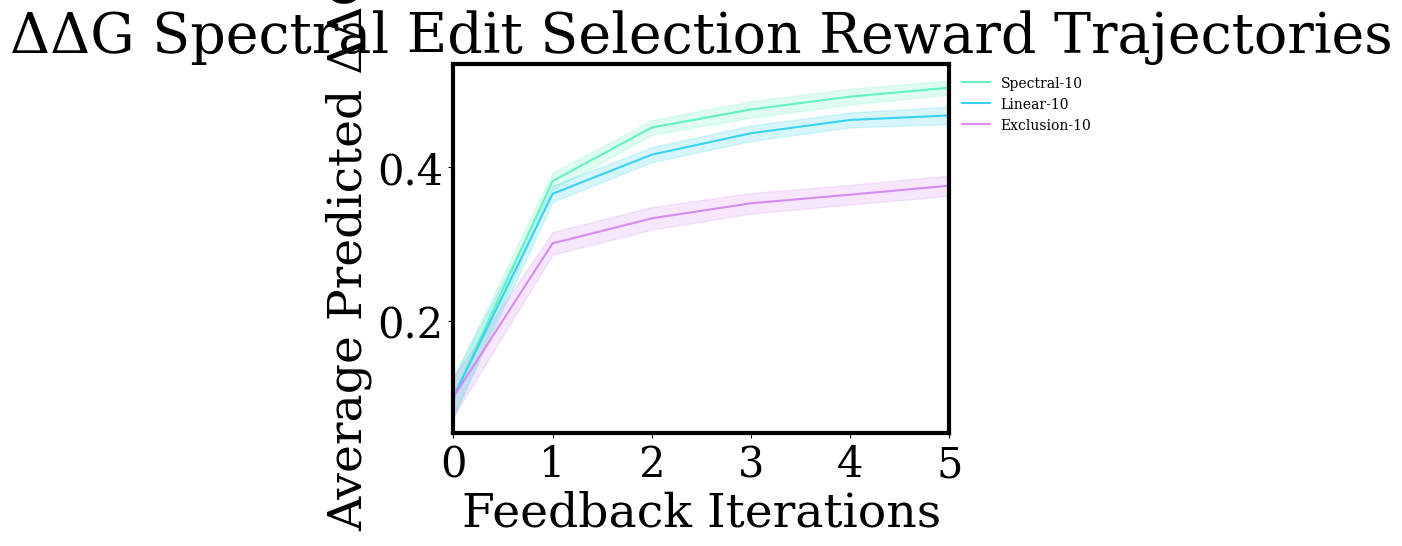

In [46]:
dfs = [spec10_df, lsq10_df, ex10_df]
names = ['Spectral-10', 'Linear-10', 'Exclusion-10']
colors = ["#61F4BC", "#3AD2F2", "#D68BF2"]

traj_full_comp(dfs, names, colors, show_baselines=False)

In [47]:
lasso_128 = test_dir + 'pretrained_validation_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=lasso_maxspecorder=10_masks=128_rmax=False_lassolambda=1e-05.csv'
max_128 = test_dir + 'pretrained_validation_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=max-mask_maxspecorder=10_masks=128_rmax=False.csv'
spec_128 = test_dir + 'pretrained_validation_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=128_rmax=False_"num_leaves"=50_"learning_rate"=0.01_"max_depth"=5_"lambda_l1"=0.00001.csv'
spec_med = valid_dir + 'anvil_data/pretrained_validation_ddg_bon_N=1_feedbacksteps=3_feedbackmethod=spectral_maxspecorder=10_masks=2048_rmax=False_"num_leaves"=50_"learning_rate"=0.01_"max_depth"=5_"lambda_l1"=0.0001.csv'
spec_big = valid_dir + 'anvil_data/pretrained_validation_ddg_bon_N=1_feedbacksteps=3_feedbackmethod=spectral_maxspecorder=10_masks=32768_rmax=False_"num_leaves"=50_"learning_rate"=0.01_"max_depth"=5_"lambda_l1"=0.0001.csv'
lasso_med = valid_dir + 'anvil_data/pretrained_validation_ddg_bon_N=1_feedbacksteps=3_feedbackmethod=lasso_maxspecorder=10_masks=2048_rmax=False_lassolambda=0.00001.csv'

lst_128 = [max_128, lasso_128, lasso_med]
df_128 = []

for fn in lst_128:
    df = pd.read_csv(fn)
    df_128.append(df)
    stats = get_eval_stats(df, target_protein=target_protein, summary_func=summary_func)
    print(stats['ddg_align'], stats['ddg'])

names = ['Max Mask-128', 'Lasso-128', 'Lasso-2048']
colors = ["#61F4BC", "#3AD2F2", "#D68BF2", "#9B59B6", "#BC5353", "#F1C40F"]
traj_full_comp(df_128, names, colors, show_baselines=False)

FileNotFoundError: [Errno 2] No such file or directory: '/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/test/pretrained_validation_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=max-mask_maxspecorder=10_masks=128_rmax=False.csv'

In [ ]:
# dfs = [spec10_tar_df, lsq10_tar_df, ex10_tar_df]
# names = ['Spectral-10', 'Linear-10', 'Exclusion-10']
# colors = ["#61F4BC", "#3AD2F2", "#D68BF2"]

# traj_full_comp(dfs, names, colors, show_baselines=False, title="HEEH_KT_rd6_0746 ΔΔG Edit Selection Baselines")

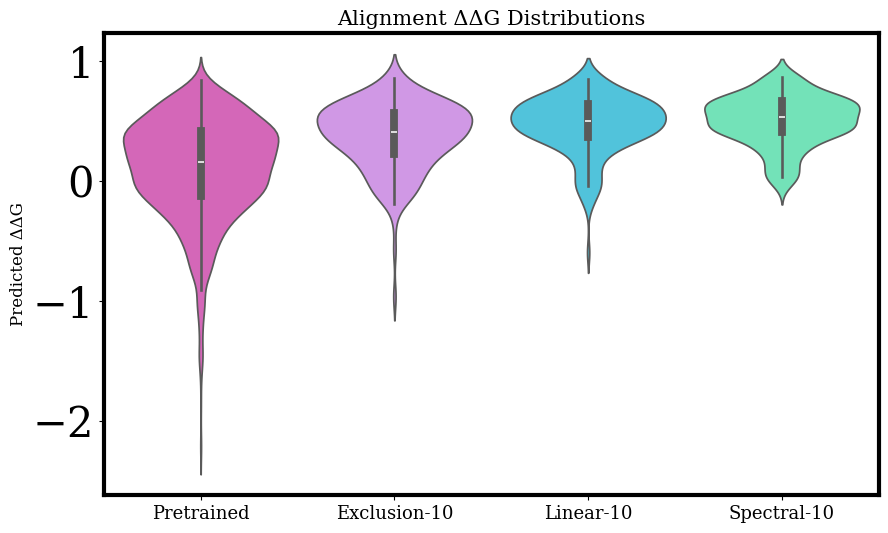

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming you have already defined dfs, names, and colors
dfs = [spec10_df, lsq10_df, ex10_df, pretrained_df]
names = ['Spectral-10', 'Linear-10', 'Exclusion-10', 'Pretrained']
colors = ["#61F4BC", "#3AD2F2", "#D68BF2", "#E655C1"]

dfs_filtered, names, colors = zip(*reversed(list(zip(dfs, names, colors))))

# dfs_filtered = [
#     df[df['protein_name'] == 'HEEH_KT_rd6_0746.pdb'] for df in dfs
# ]

# Prepare the data by concatenating the filtered DataFrames
df_combined = pd.concat([df[['ddg']].assign(Experiment=name) for df, name in zip(dfs_filtered, names)])

# Create a violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Experiment', y='ddg', data=df_combined, palette=colors, legend=False, hue='Experiment')

# Customize the plot
plt.title(f'Alignment ΔΔG Distributions', fontsize=15)
plt.xlabel('')
plt.ylabel('Predicted ΔΔG', fontsize=12)
plt.xticks(fontsize=13)
plt.show()

Spec-10 BoN-10 [0.69672304 0.71524641 0.72565536 0.73485568 0.73560379]
Linear-10 BoN-10 [0.43089554 0.43156593 0.43906558 0.44582615 0.44415055]


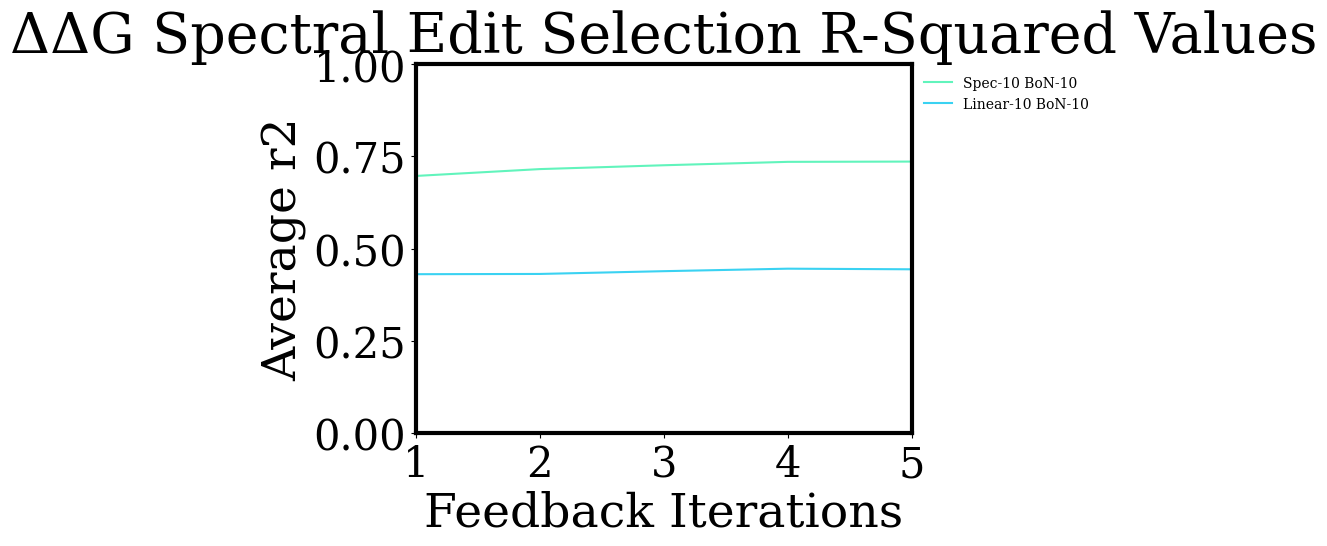

In [49]:
dfs = [spec10_bon10_df, lsq10_bon10_df]
names = ['Spec-10 BoN-10', 'Linear-10 BoN-10']
colors = ["#61F4BC", "#3AD2F2"]

traj_r2_comp(dfs, names, colors)

In [50]:
# dfs = [spec10_ll_df, lsq10_ll_df, ex10_ll_df]
# names = ['Spec-10', 'Linear-10', 'Exclusion-10']
# colors = ["#61F4DE","#3AD2F2", "#D68BF2"]

# traj_col = 'spec_trajectory'
# ylabel = "Average ProtGPT2 Negative Log Likelihood"
# ylim = None
# it_space = None
# title = "Edit Selection Log Likelihood Alignment Trajectories"

# display_traj(dfs, names, traj_col, ylabel, colors=colors, ylim=ylim, it_space=it_space, target_protein=target_protein, title=title, show_bon=False, show_err=True)

Spec-10 [0.79671522 0.78724372 0.79265358 0.79899127 0.79882427]
Linear-10 [0.50090975 0.44071295 0.44813972 0.45121991 0.46220412]


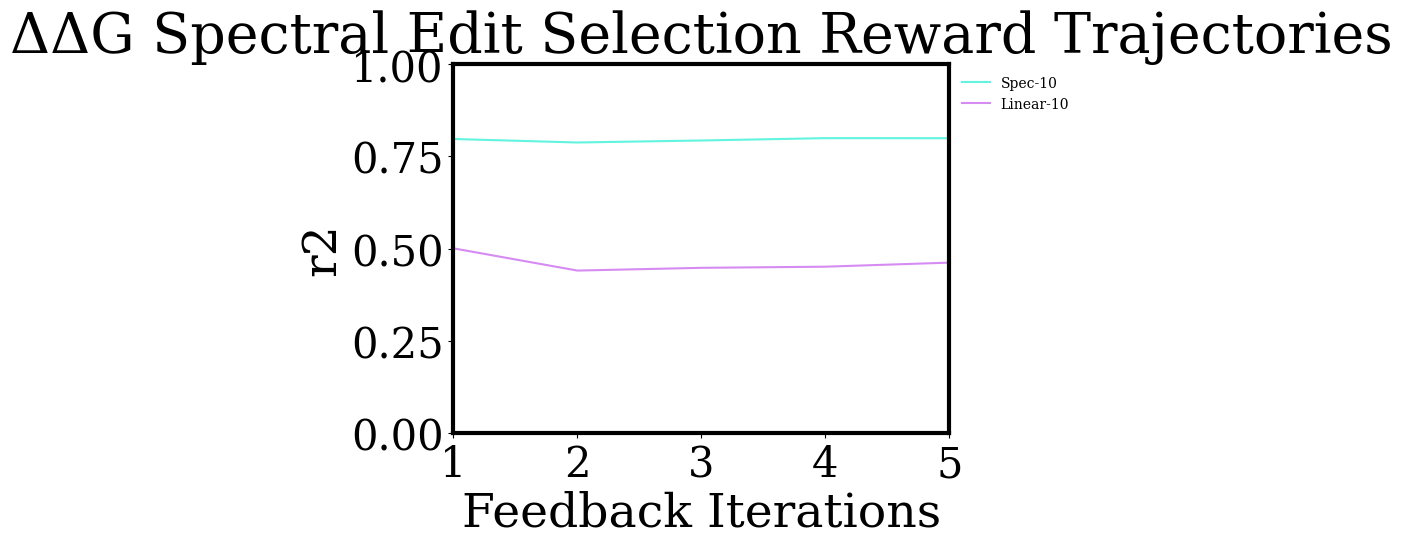

In [51]:
traj_col = 'r2_trajectory'
ylabel = "r2"
ylim = (0, 1)
it_space = np.arange(1, 6, 1)
title = "ΔΔG Spectral Edit Selection Reward Trajectories"

display_traj([spec10_df, lsq10_df], ['Spec-10', 'Linear-10'], traj_col, ylabel, colors=['#61F4DE','#D68BF2'], ylim=ylim, it_space=it_space, target_protein=target_protein, title=title, show_err=False)

In [52]:
# traj_col = 'r2_trajectory'
# ylabel = "r2"
# ylim = (0, 1)
# it_space = np.arange(1, 6, 1)
# title = "Log Likelihood Spectral Edit Selection R-Squared Values"

# display_traj([spec5_ll_df, spec10_ll_df], ['Spec-5', 'Spec-10'], traj_col, ylabel, colors=colors, ylim=ylim, it_space=it_space, target_protein=target_protein, title=title, show_err=False)

In [53]:
import random 

def evaluate_scrmsd_ll_corr_mult(df_list, labels, protein, title='', selected_samples=None, colors=None, ylabel='loglikelihood', yname='Log Likelihood'):
    for i, df in enumerate(df_list):
        if protein is not None:
            df = df[df['protein_name'] == protein + ".pdb"]
        pre_ddg = df['scrmsd']
        pre_protgpt = df[ylabel]
        if selected_samples is not None and len(pre_ddg) > selected_samples: # type: ignore
            ids = random.sample(range(len(pre_ddg)), selected_samples) # type: ignore
            pre_ddg = np.array(pre_ddg)[ids]
            pre_protgpt = np.array(pre_protgpt)[ids]
        if colors is not None:
            plt.scatter(pre_ddg, pre_protgpt, label=labels[i], c=colors[i])
        else:
            plt.scatter(pre_ddg, pre_protgpt, label=labels[i])
    plt.xlabel('scRMSD')
    plt.ylabel(yname)
    plt.title(title)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, frameon=False)
    plt.show()

In [54]:
def evaluate_ddg_ll_corr_mult(df_list, labels, protein, title='', selected_samples=None, colors=None, ddg_label='ddg_eval', ylabel='loglikelihood', yname='Log Likelihood'):
    for i, df in enumerate(df_list):
        if protein is not None:
            df = df[df['protein_name'] == protein + ".pdb"]
        pre_ddg = df[ddg_label]
        pre_protgpt = df[ylabel]
        if selected_samples is not None and len(pre_ddg) > selected_samples: # type: ignore
            ids = random.sample(range(len(pre_ddg)), selected_samples) # type: ignore
            pre_ddg = np.array(pre_ddg)[ids]
            pre_protgpt = np.array(pre_protgpt)[ids]
        if colors is not None:
            plt.scatter(pre_ddg, pre_protgpt, label=labels[i], c=colors[i])
        else:
            plt.scatter(pre_ddg, pre_protgpt, label=labels[i])
    if ddg_label == 'ddg_eval':
        plt.xlabel('ΔΔG Eval')
    else:
        plt.xlabel('ΔΔG Align')
    plt.ylabel(yname)
    plt.title(title)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, frameon=False)
    plt.show()

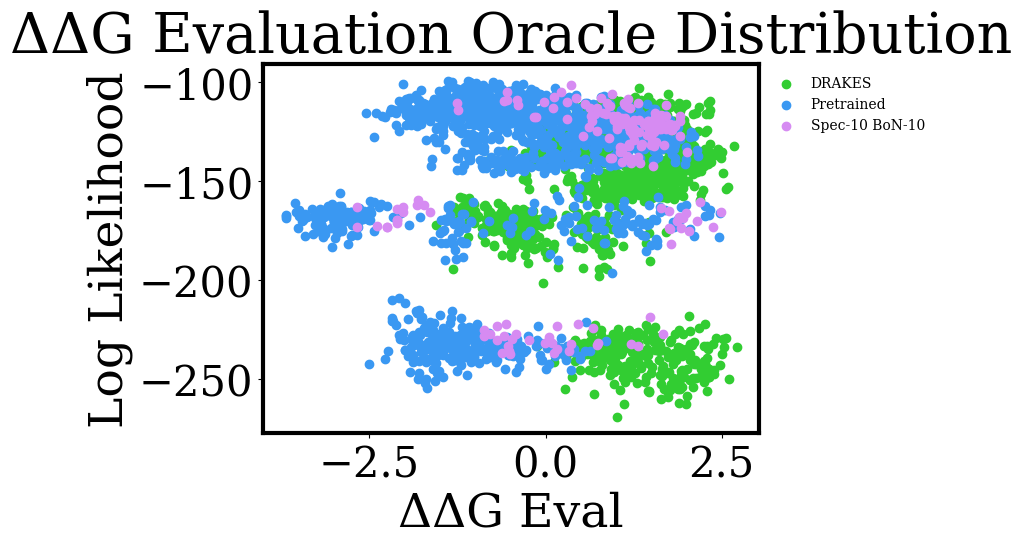

In [55]:
df_list = [drakes_df, pretrained_df, spec10_bon10_df]
labels = ["DRAKES", "Pretrained", "Spec-10 BoN-10"]
colors = ["limegreen", "#3A98F2", "#D68BF2"]
protein = target_protein
title = f'{protein} ΔΔG Evaluation Oracle Distribution' if protein is not None else "ΔΔG Evaluation Oracle Distribution"
evaluate_ddg_ll_corr_mult(df_list, labels, protein, title=title, selected_samples=None, colors=colors, ddg_label='ddg_eval')

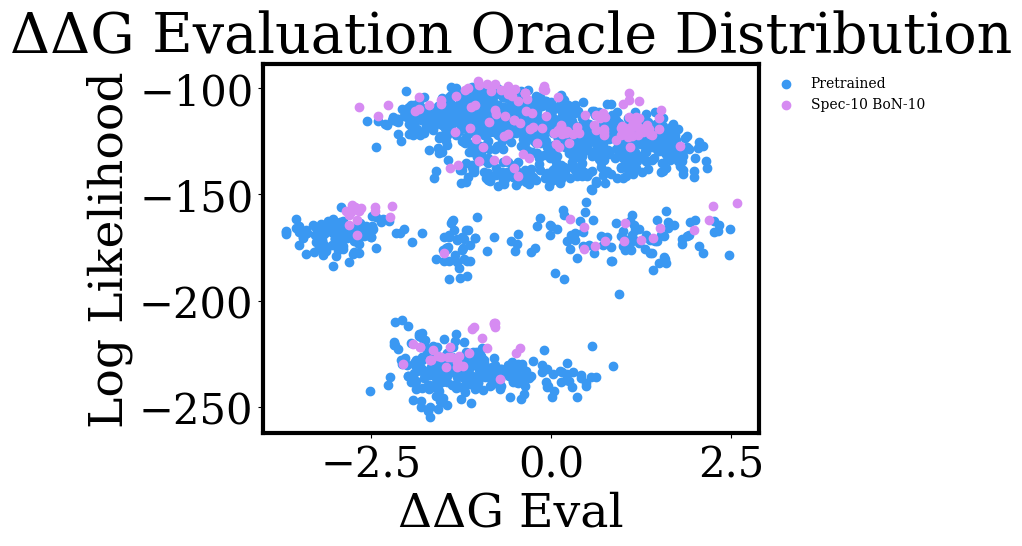

In [56]:
df_list = [pretrained_df, spec10_bon10_ll_df]
labels = ["Pretrained","Spec-10 BoN-10"]
colors = ["#3A98F2", "#D68BF2"]
protein = target_protein
title = f'{protein} ΔΔG Evaluation Oracle Distribution' if protein is not None else "ΔΔG Evaluation Oracle Distribution"
evaluate_ddg_ll_corr_mult(df_list, labels, protein, title=title, selected_samples=None, colors=colors, ddg_label='ddg_eval')

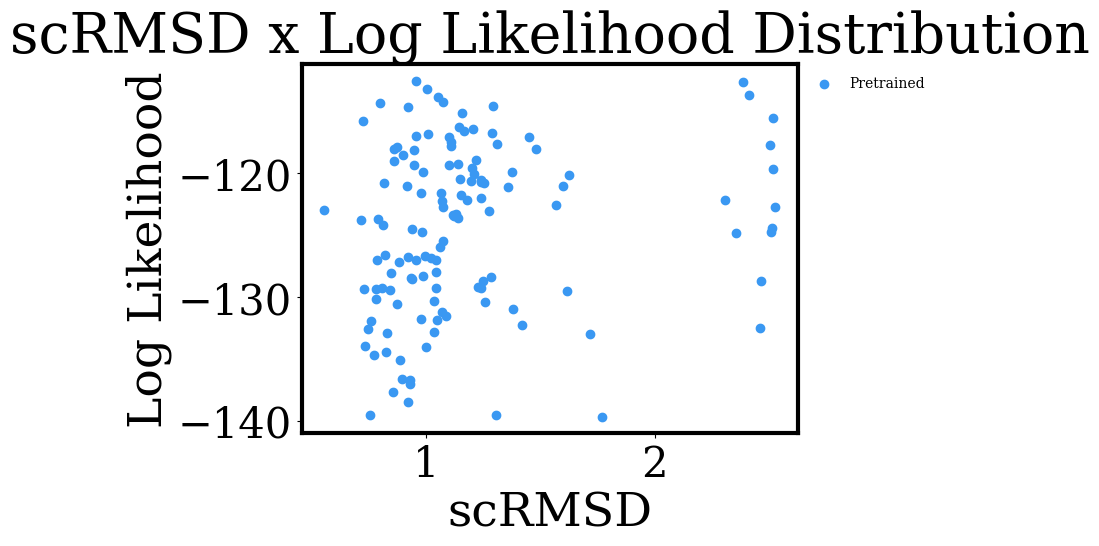

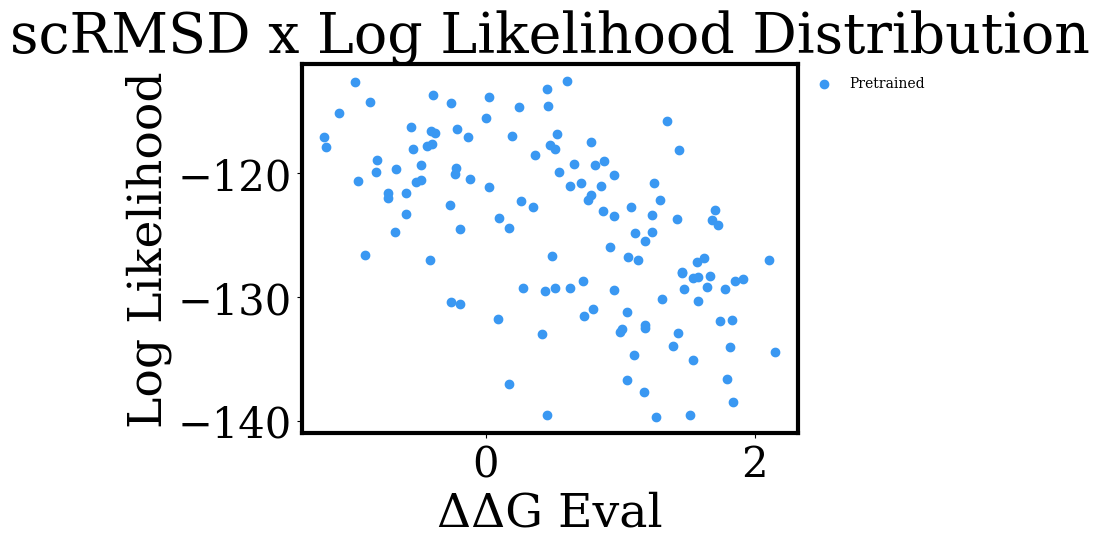

In [57]:
df_list = [pretrained_df]
labels = ["Pretrained"]
colors = ["#3A98F2",]
protein = target_protein
title = 'scRMSD x Log Likelihood Distribution'
evaluate_scrmsd_ll_corr_mult(df_list, labels, '7JJK', title=title, selected_samples=None, colors=colors)
evaluate_ddg_ll_corr_mult(df_list, labels, '7JJK', title=title, selected_samples=None, colors=colors)

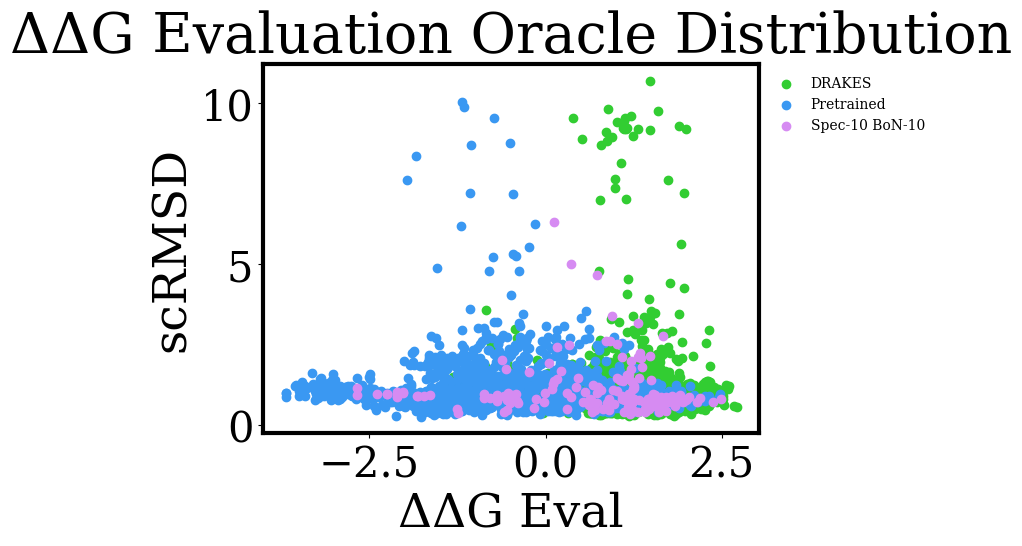

In [58]:
df_list = [drakes_df, pretrained_df, spec10_bon10_df]
labels = ["DRAKES", "Pretrained", "Spec-10 BoN-10"]
colors = ["limegreen", "#3A98F2", "#D68BF2"]
protein = target_protein
title = f'{protein} ΔΔG Evaluation Oracle Distribution' if protein is not None else "ΔΔG Evaluation Oracle Distribution"
evaluate_ddg_ll_corr_mult(df_list, labels, protein, title=title, selected_samples=None, colors=colors, ddg_label='ddg_eval', ylabel='scrmsd', yname='scRMSD')

In [59]:
title = f'{protein} ΔΔG Alignment Oracle Distribution' if protein is not None else "ΔΔG Alignment Oracle Distribution"
evaluate_ddg_ll_corr_mult(df_list, labels, protein, title=title, selected_samples=None, colors=colors, ddg_label='ddg')

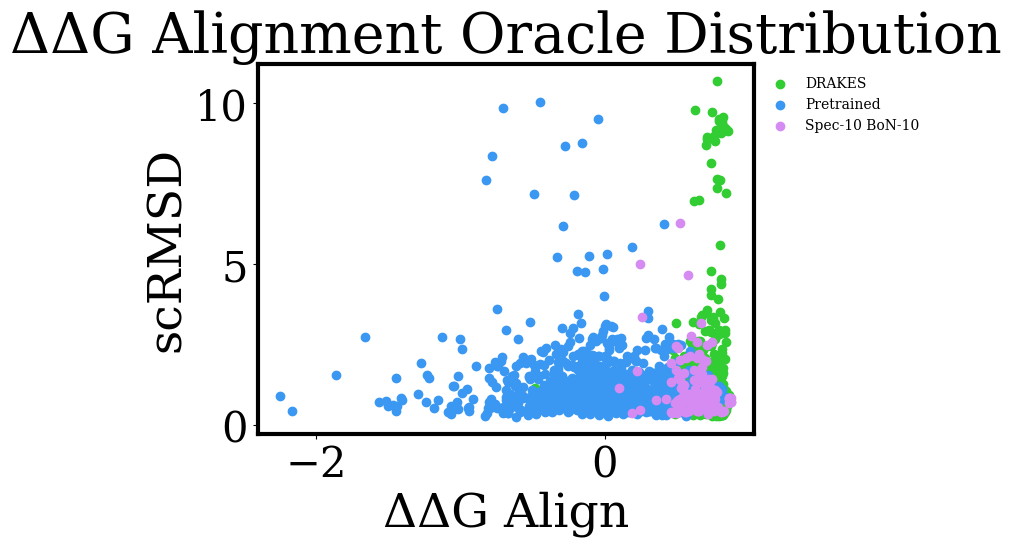

In [60]:
title = f'{protein} ΔΔG Alignment Oracle Distribution' if protein is not None else "ΔΔG Alignment Oracle Distribution"
evaluate_ddg_ll_corr_mult(df_list, labels, protein, title=title, selected_samples=None, colors=colors, ddg_label='ddg', ylabel='scrmsd', yname='scRMSD')

In [61]:
# 2KRU
base_2kru = 'ELSWTAEAEKMLGKVPFFVRKKVRKNTDNYAREIGEPVVTADVFRKAKEHLG'
base_r6 = 'AKPPKTVTVKVEVTNADGETQTRTVTLTNLPKDLKPGDTVTLPETGQTARIVEITP'

print(len(base_2kru))
print(len(base_r6))

52
56


In [62]:
import ast

def count_step_interactions(dfs, exp_labels, target_protein=None):
    res = {}

    for df, exp_label in zip(dfs, exp_labels):
        if target_protein is not None:
            protein_names = [target_protein + '.pdb']
        else:
            protein_names = np.unique(df['protein_name'])

        feedback_its = len(ast.literal_eval(df.iloc[0]["spec_selections"]))

        total_counts = [[] for _ in range(feedback_its)]

        for name in protein_names:
            df_filt = df[df['protein_name'] == name]
            protein_len = len(df_filt.iloc[0]['true_seq'])

            for i in range(feedback_its): total_counts[i].append(np.zeros(protein_len, dtype=int))

            for row in df_filt.itertuples():
                selections = ast.literal_eval(row.spec_selections) # type: ignore
                for i, s in enumerate(selections):
                    for j in s:
                        total_counts[i][-1][j] += 1

        res[exp_label] = total_counts

    return res

Linear-10 BoN-10 [0.5714285714285714, 0.6785714285714286, 1.1428571428571428, 0.6071428571428571, 1.0714285714285712]
Exclusion-10 BoN-10 [0.9285714285714285, 1.2857142857142856, 1.6071428571428572, 1.285714285714286, 1.785714285714286]


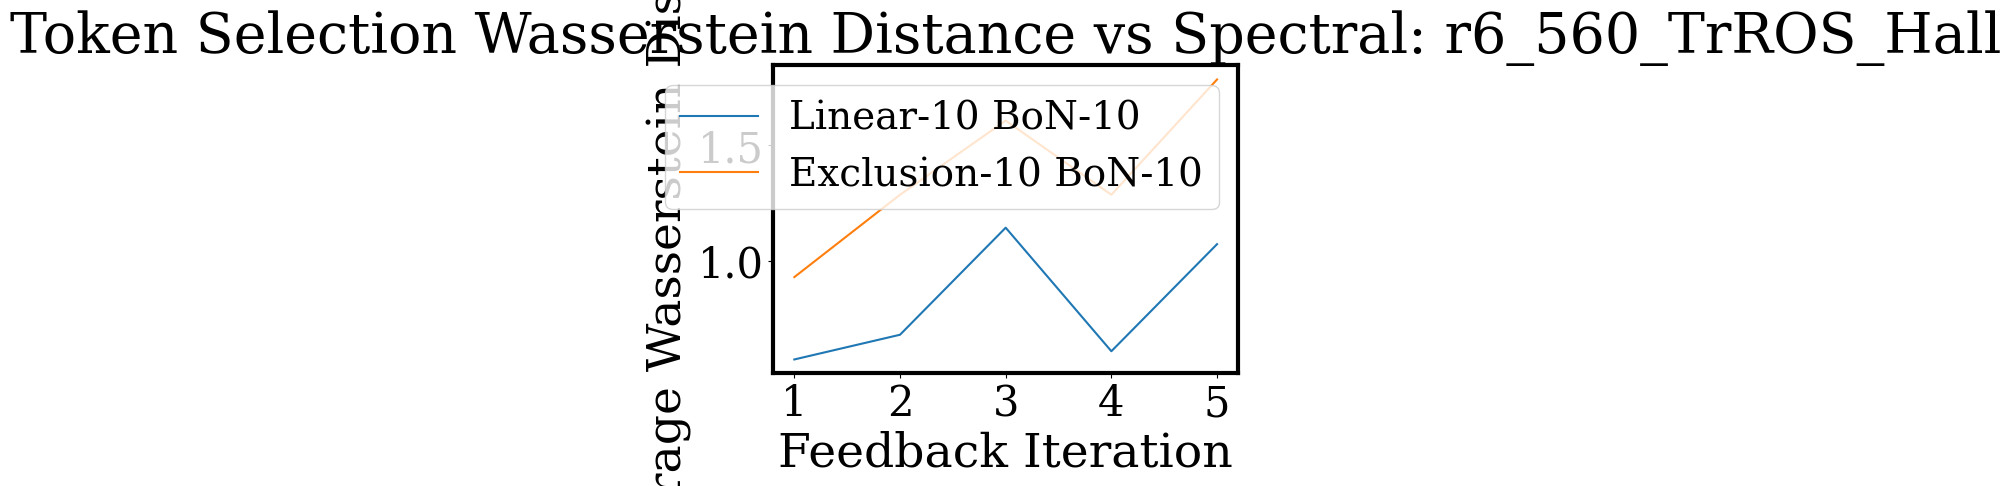

Linear-10 BoN-10 [0.38461538461538464, 0.3846153846153847, 0.5384615384615383, 0.30769230769230743, 0.34615384615384637]
Exclusion-10 BoN-10 [0.6153846153846154, 1.307692307692308, 2.076923076923077, 1.9230769230769234, 2.0384615384615383]


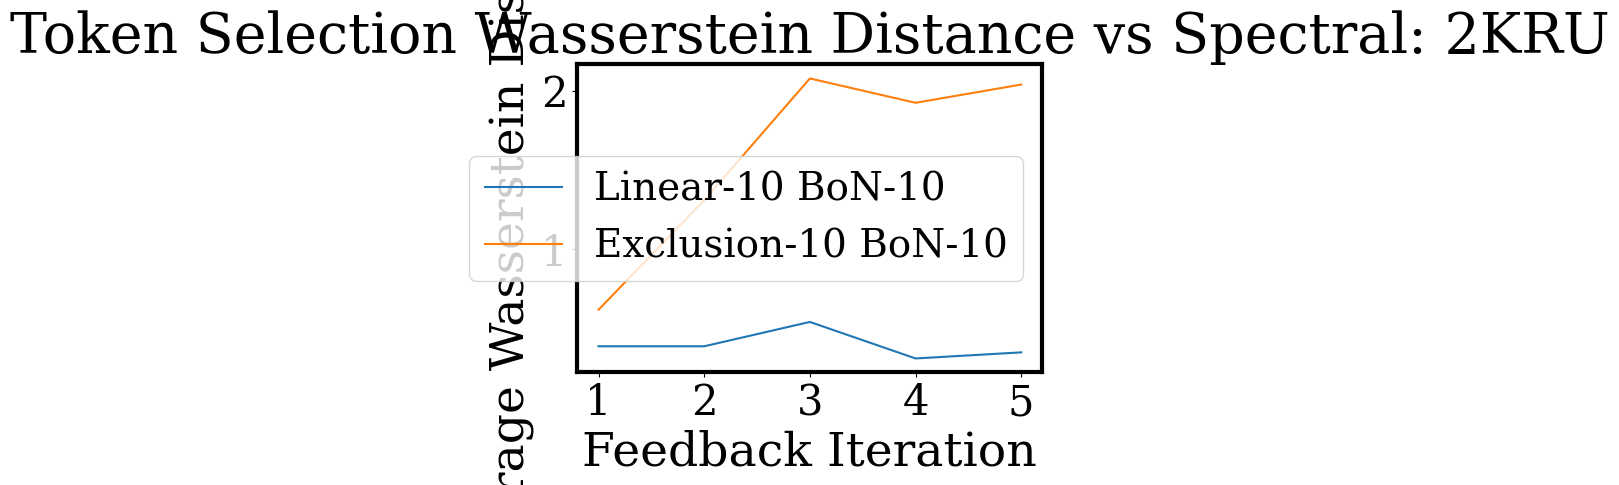

In [63]:
from scipy.stats import wasserstein_distance

dfs = [spec10_bon10_df, lsq10_bon10_df, ex10_bon10_df]
exp_labels = ['Spectral-10 BoN-10', 'Linear-10 BoN-10', 'Exclusion-10 BoN-10']

for protein in ['r6_560_TrROS_Hall', '2KRU']:
    res = count_step_interactions(dfs, exp_labels, protein)

    spec_select = res[exp_labels[0]]

    all_wasserstein = {}

    compare_labels = exp_labels[1:]

    for label in compare_labels:
        wassersteins = []
        for feedback_it in range(len(spec_select)):
            wasserstein_avg = 0.0
            for s, s_comp in zip(spec_select[feedback_it],res[label][feedback_it]):
                wasserstein_avg += wasserstein_distance(s, s_comp)
            wassersteins.append(wasserstein_avg / len(spec_select[feedback_it]))
        all_wasserstein[label] = wassersteins

    fig, ax = plt.subplots(figsize=(6,4))

    bins = np.arange(1, len(spec_select) + 1, dtype=int)
    for label in compare_labels:
        print(label, all_wasserstein[label])
        ax.plot(bins, all_wasserstein[label], label=label)

    ax.set_xlabel("Feedback Iteration")
    ax.set_ylabel("Average Wasserstein Distance")
    ax.set_xticks(bins)
    ax.legend()

    title = "Token Selection Wasserstein Distance vs Spectral"
    if protein is not None:
        title += f": {protein}"
    plt.title(title)
    plt.show()

In [64]:
# it = 1
# for target, name in [(f"r6_it{it}", "r6_560_TrROS_Hall"), (f"2kru_it{it}", "2KRU")]:
#     with open(f"DRAKES/drakes_protein/fmif/fourier_{target}.txt", "r") as f:
#         fourier_coeffs = np.array(f.readlines(), dtype=float)
#         print(len(fourier_coeffs))
#         fourier_coeffs = np.array(sorted(np.abs(fourier_coeffs))[:-1])
#         # print(fourier_coeffs[-2:])
#         # print(sorted(fourier_coeffs)[-2:])

#         plt.hist(fourier_coeffs, weights=np.full_like(fourier_coeffs, 1. / fourier_coeffs.size), bins=150, alpha=1.0, color='cornflowerblue')
#         plt.yscale('log')
#         plt.ylabel("Frequency")
#         plt.xlim(-0.01, 0.15)
#         plt.ylim(1e-5,1.25)
#         plt.xlabel("Fourier Coefficient Magnitude")
#         plt.title(name.replace("_", "-") + " Spectral Feedback Fourier Coefficients")
#         plt.show()

In [65]:
DSR_r6_hall_it1 = [(8, 0.75), (16, 0.8541666666666666), (32, 0.8645833333333334), (64, 0.9322916666666667), (128, 0.8717447916666667), (256, 0.899479166666666)]
DSR_2kru_it1 = [(8, 0.875), (16, 0.9166666666666666), (32, 0.890625), (64, 0.9374999999999999), (128, 0.9264322916666667), (256, 0.9228515624999999)]

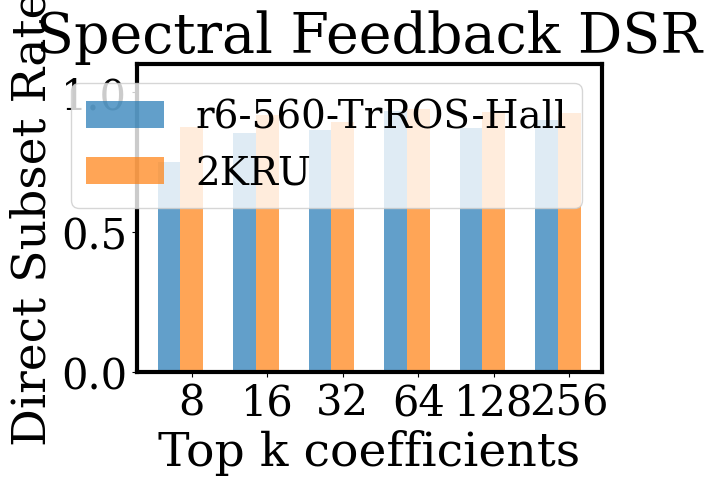

In [66]:
bar_width = 0.3
fig = plt.subplots(figsize =(6, 4)) 

br1 = np.arange(len(DSR_r6_hall_it1)) 
br2 = [x + bar_width for x in br1] 

plt.bar(br1, [x[1] for x in DSR_r6_hall_it1], width=bar_width, alpha=0.7, label='r6-560-TrROS-Hall')
plt.bar(br2, [x[1] for x in DSR_2kru_it1], width=bar_width, alpha=0.7, label='2KRU')
plt.xlabel("Top k coefficients")
plt.ylabel("Direct Subset Rate")
plt.title("Spectral Feedback DSR")
plt.ylim(0,1.1)
plt.xticks([r + bar_width for r in range(len(DSR_r6_hall_it1))], [str(x[0]) for x in DSR_r6_hall_it1])

plt.legend()
plt.show()

In [67]:
SHR_r6_hall_it1 = [(8, 0.75), (16, 0.8125), (32, 0.75), (64, 0.8125), (128, 0.6875), (256, 0.76171875)]
SHR_2kru_it1 = [(8, 1.0), (16, 0.8125), (32, 1.0), (64, 0.921875), (128, 0.8046875), (256, 0.76171875)]

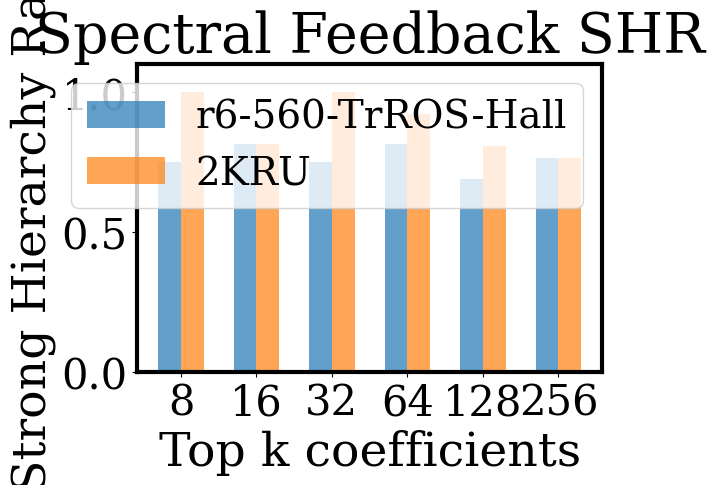

In [68]:
bar_width = 0.3
fig = plt.subplots(figsize =(6, 4)) 

br1 = np.arange(len(DSR_r6_hall_it1)) + 0.5 * bar_width
br2 = [x + bar_width for x in br1] 

plt.bar(br1, [x[1] for x in SHR_r6_hall_it1], width=bar_width, alpha=0.7, label='r6-560-TrROS-Hall')
plt.bar(br2, [x[1] for x in SHR_2kru_it1], width=bar_width, alpha=0.7, label='2KRU')
plt.xlabel("Top k coefficients")
plt.ylabel("Strong Hierarchy Rate")
plt.title("Spectral Feedback SHR")

plt.xticks([r + bar_width for r in range(len(DSR_r6_hall_it1))], [str(x[0]) for x in DSR_r6_hall_it1])
plt.ylim(0,1.1)

plt.legend()
plt.show()

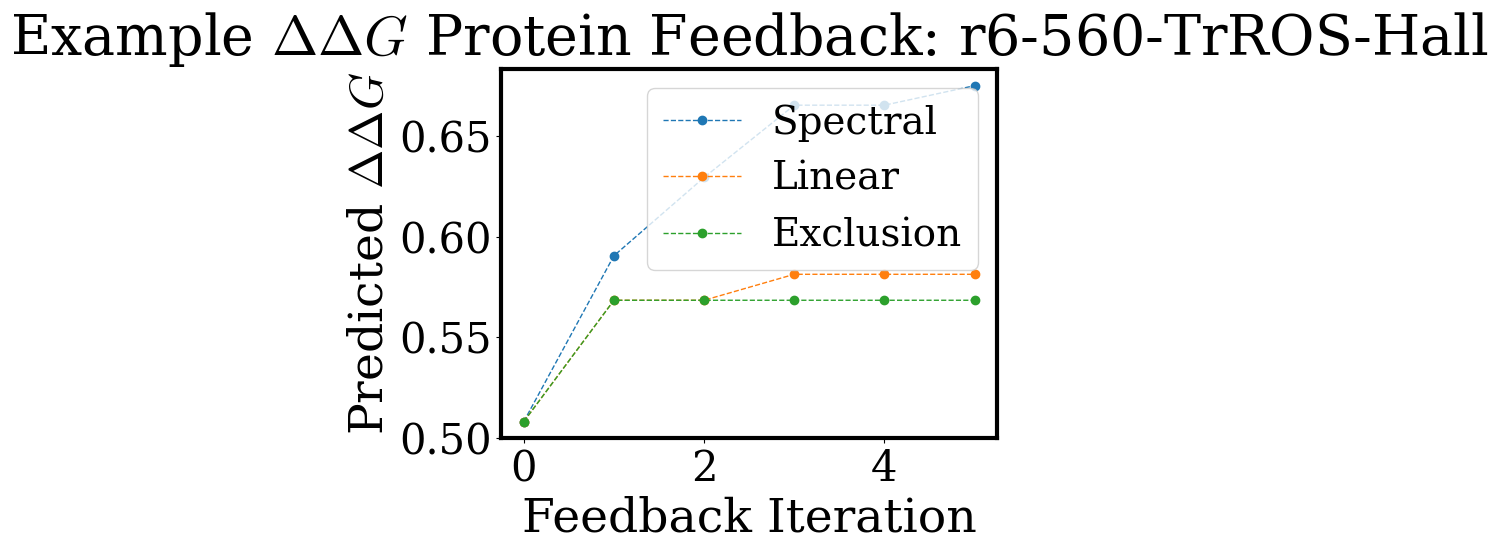

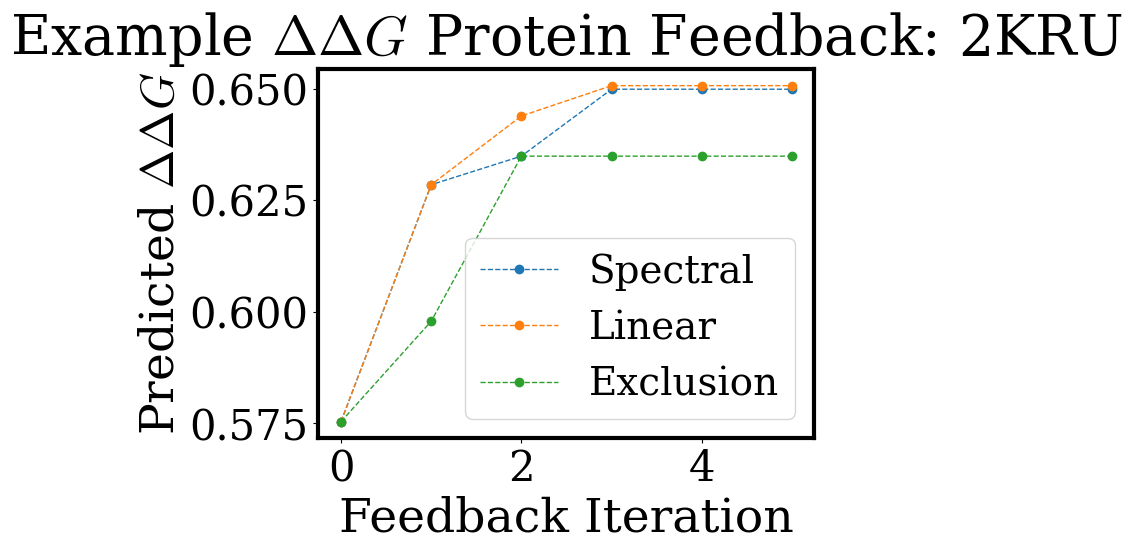

In [69]:
def display_res(res, target_name):
    spec_traj = res['spec_traj']
    linear_traj = res['linear_traj']
    ex_traj = res['ex_traj']

    its = np.arange(0, len(spec_traj))
    traj_lst = [spec_traj, linear_traj, ex_traj]
    traj_names = ["Spectral", "Linear", "Exclusion"]

    for i, (traj, name) in enumerate(zip(traj_lst, traj_names)): 
        plt.plot(its, traj, label=name, linewidth='1', linestyle='--', marker='o')
    plt.xlabel("Feedback Iteration")
    plt.ylabel(r"Predicted $\Delta \Delta G$")
    plt.legend()
    plt.title(r"Example $\Delta \Delta G$ Protein Feedback: " + target_name)
    plt.show()

res_hall = {
    "spec_traj":[0.5081, 0.5905, 0.6294, 0.6653, 0.6653, 0.675],
    "linear_traj":[0.5081, 0.5684, 0.5684, 0.5813, 0.5813, 0.5813],
    "ex_traj":[0.5081, 0.5684, 0.5684, 0.5684, 0.5684, 0.5684]
}

target1 = 'r6-560-TrROS-Hall'

res_2kru = {
    "spec_traj":[0.5754, 0.6285, 0.6349, 0.6499, 0.6499, 0.6499],
    "linear_traj":[0.5754, 0.6285, 0.6439, 0.6507, 0.6507, 0.6507],
    "ex_traj":[0.5754, 0.5979, 0.6349, 0.6349, 0.6349, 0.6349]
}

target2 = '2KRU'

display_res(res_hall, target1)
display_res(res_2kru, target2)

In [70]:
spec_hall_r2 = [0.7109, 0.811, 0.815, 0.8075, 0.8121]
lsq_hall_r2 = [0.4251, 0.3778, 0.3621, 0.4, 0.4019]

spec_2kru_r2 = [0.7296, 0.6981, 0.7774, 0.7881, 0.7844]
lsq_2kru_r2 = [0.3986, 0.3209, 0.4147, 0.421, 0.4006]

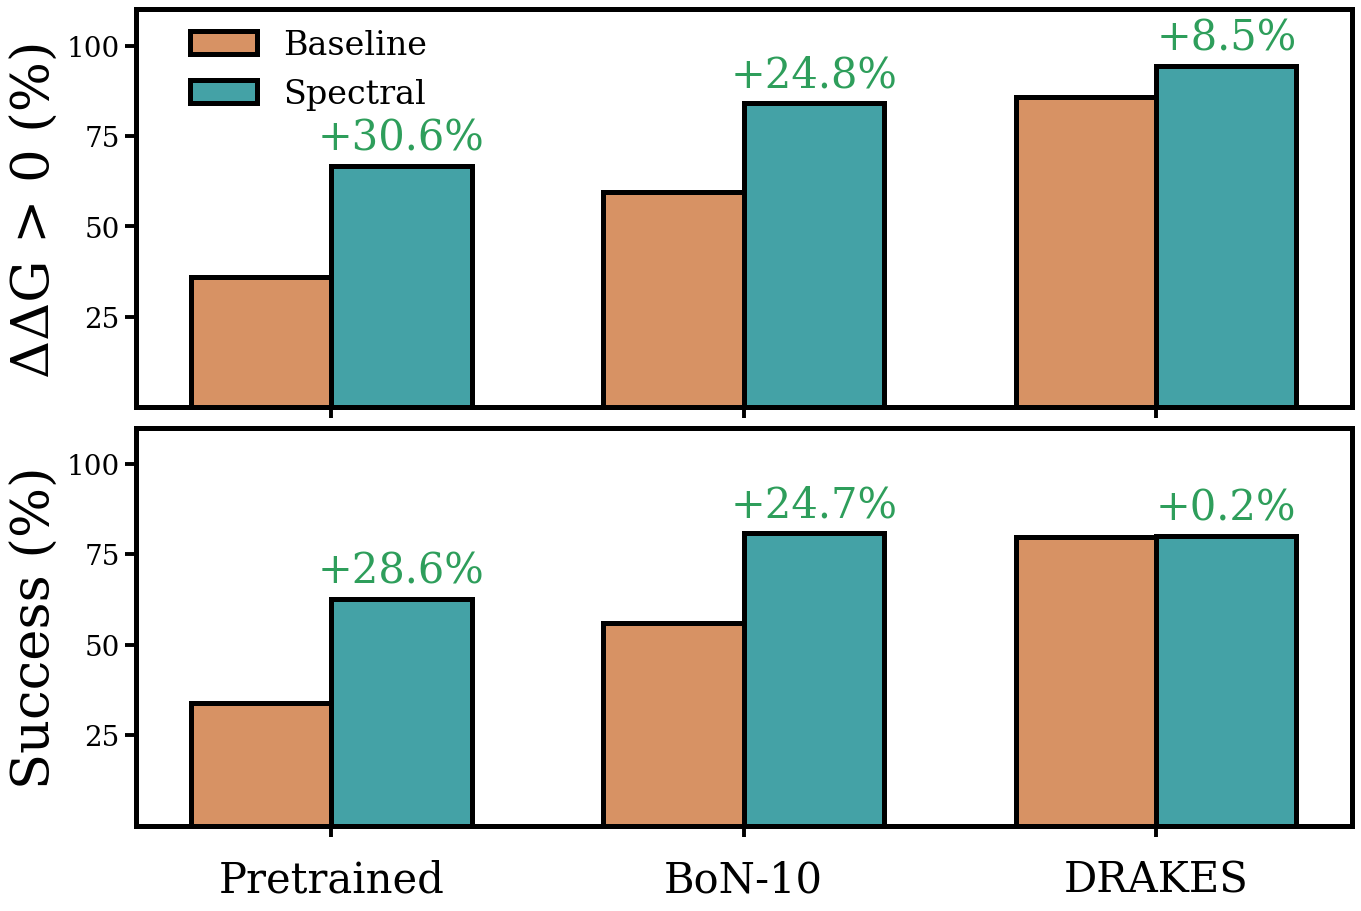

Saved: /home/shai/NeuripsProtein2026/Figures/spec53_ddg_success_before_after_square.pdf


In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Visual style matched to the provided reference figure.
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.linewidth": 3.0,
    "axes.labelweight": "regular",
    "axes.titleweight": "regular",
    "axes.titlesize": 34,
    "axes.labelsize": 26,
    "xtick.labelsize": 18,
    "ytick.labelsize": 20,
    "legend.fontsize": 24,
})

# Values from NeuripsProtein2026, Sec. 5.3 table.
methods = ["Pretrained", "BoN-10", "DRAKES"]

ddg_before = np.array([36.1, 59.4, 85.9])
ddg_after  = np.array([66.7, 84.2, 94.4])

success_before = np.array([33.9, 56.1, 79.8])
success_after  = np.array([62.5, 80.8, 80.0])

# Reference-style colors.
before_color = "#D79264"  # warm orange
after_color = "#44A2A6"   # teal
delta_green = "#2E9E5B"   # clean, readable green

x = np.arange(len(methods))
width = 0.34
# Square figure with top and bottom halves.
fig, axes = plt.subplots(2, 1, figsize=(9.0 * 1.5, 9.0), sharex=True, constrained_layout=True)

# ---------------- Top half: DDG > 0 (%) ----------------
ax = axes[0]
ax.bar(x - width/2, ddg_before, width, color=before_color, edgecolor="black", linewidth=3.6, label="Baseline")
ax.bar(x + width/2, ddg_after,  width, color=after_color,  edgecolor="black", linewidth=3.6, label="Spectral")

ax.set_ylabel("ΔΔG > 0 (%)", fontsize=38)
ax.set_ylim(0, 110)
ax.set_yticks([25, 50, 75, 100])
ax.legend(loc="upper left", bbox_to_anchor=(0.02, 1.025), frameon=False)

for i, (before, after) in enumerate(zip(ddg_before, ddg_after)):
    ax.text(
        x[i] + width/2,
        after + 2.0,
        f"+{after-before:.1f}%",
        ha="center",
        va="bottom",
        fontsize=30,
        color=delta_green,
    )

# ---------------- Bottom half: Success Rate (%) ----------------
ax2 = axes[1]
ax2.bar(x - width/2, success_before, width, color=before_color, edgecolor="black", linewidth=3.6)
ax2.bar(x + width/2, success_after,  width, color=after_color,  edgecolor="black", linewidth=3.6)

ax2.set_ylabel("Success (%)", fontsize=38)
ax2.set_ylim(0, 110)
ax2.set_yticks([25, 50, 75, 100])
ax2.set_xticks(x)
ax2.set_xticklabels(methods, fontsize=30)
ax2.tick_params(axis="x", pad=16)

for i, (before, after) in enumerate(zip(success_before, success_after)):
    ax2.text(
        x[i] + width/2,
        after + 2.0,
        f"+{after-before:.1f}%",
        ha="center",
        va="bottom",
        fontsize=30,
        color=delta_green,
    )

# Reference-like heavy spines and no grid lines.
for a in axes:
    a.grid(False)
    for spine in a.spines.values():
        spine.set_linewidth(3.6)
    a.tick_params(axis="both", width=2.8, length=8)

out_path = "/home/shai/NeuripsProtein2026/Figures/spec53_ddg_success_before_after_square.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved: {out_path}")